# A 10-pulsar ATLAS global fit on *simulated* data

### Same model as `three_pulsar_global_fit.ipynb` — GWB, intrinsic red noise, white noise and a directly-sampled linear timing model — but on a dataset whose true parameters we know

This notebook runs the **identical analysis configuration** as the 3-pulsar tutorial, on
ten pulsars drawn from `datasets/sim_NG15_01`. The point of the change is that this
dataset is *simulated*, so every quantity we sample has a known injected value and every
posterior in §12 can be checked against a truth rather than against a plausibility
argument.

| Component | Model | Sampled? | Truth known? |
|---|---|---|---|
| Linearised timing model $\epsilon$ | design matrix $M$, flat prior | **yes** — directly, as basis coefficients | n/a (residuals are post-fit) |
| White noise | EFAC, EQUAD, ECORR per backend | **yes** — varied inside the likelihood | **yes** — `injected_params.json` |
| Intrinsic red noise (IRN) | power law, per pulsar | **yes** — $\log_{10}A$, $\gamma$ | **yes** |
| GWB | power law + Hellings–Downs ORF | **yes** — $\log_{10}A$, $\gamma$ | **yes** — $A = 2.4\times10^{-15}$, $\gamma = 13/3$ |

Everything is in **one posterior**, sampled with NUTS. That is the entire thesis of ATLAS:
conventional PTA analysis fits and freezes the timing solution, then fits and freezes the
white noise, then linearises and marginalises the timing model, and only then samples the
spectra — so timing-model and white-noise uncertainty never propagate into the GWB
posterior. A global fit refuses that staging.

## Where the dataset came from

`notebooks/[KAG]Generating_P1_data.ipynb` built it in two steps, using
[`pta_replicator`](https://github.com/nanograv/pta_replicator):

1. **`datasets/NG15` → `datasets/ideal_NG15`.** Copy the real NANOGrav 15 yr par/tim
   files, strip `EFAC`/`EQUAD`/`ECORR`/`RNAMP`/`RNIDX` from the par files, and call
   `make_ideal`, which resets every TOA so the residuals are *exactly zero* against the
   timing solution. The observing epochs, radio frequencies, backends and TOA
   uncertainties are all preserved — only the noise is gone.
2. **`ideal_NG15` → `sim_NG15_01`.** Inject, in order: per-backend white noise
   (EFAC $\sim\mathcal N(1, 0.2)$, $\log_{10}$EQUAD and $\log_{10}$ECORR $\sim\mathcal U(-8,-5)$),
   per-pulsar power-law red noise at the NG15 maximum-likelihood values, and a
   Hellings–Downs-correlated GWB with $\log_{10}A = \log_{10}(2.4\times10^{-15}) = -14.62$,
   $\gamma = 13/3$. Every drawn value was written to
   `datasets/sim_NG15_01/injected_params.json`.

So the sampling cadence, backend structure and design matrices are exactly those of the
real array, but the noise is ours.

---

## The one thing to internalise before you start

Every piece of data in ATLAS is compressed, exactly once per likelihood evaluation, into
**four arrays**, collectively called `helpers`:

$$
\mathtt{TNT} = T^{\mathsf T} N^{-1} T \;[N_\mathrm{psr}, N_\mathrm{col}, N_\mathrm{col}],
\qquad
\mathtt{TNr} = T^{\mathsf T} N^{-1} r \;[N_\mathrm{psr}, N_\mathrm{col}],
$$
$$
\mathtt{rNr} = r^{\mathsf T} N^{-1} r \;\text{(scalar)},
\qquad
\mathtt{logdet\_N} = \log\det N \;\text{(scalar)}.
$$

Nothing downstream of `helpers` ever touches a TOA again. The whole notebook is really
just: *build the two things that make `helpers`* (a noise covariance $N$ and a design
basis $T$), *then hand `helpers` to a sampler.*

```
  par/tim  ──▶  Pulsar  ──▶  PTA_Data  ──┬──▶  WhiteCov    ──▶  N⁻¹  ──┐
                                         │     (nMatrix)              │
                                         │                            ├──▶ helpers ──▶ likelihood ──▶ NUTS
                                         └──▶  SuperSignal ──▶  T  ───┘
                                               (signals/factorized)
```

## 0. Prerequisites

ATLAS needs `jax`, `numpyro`, `enterprise-pulsar` (plus `pint-pulsar` or `libstempo` to
read par/tim), `scikit-learn`, `joblib`, `tqdm`, `tqdm_joblib`, and **JUG**.

> **Note.** `pyproject.toml` under-declares its dependencies: `scikit-learn`, `tqdm` and
> `tqdm_joblib` are hard imports on the main path but are not listed as runtime
> requirements, and JUG is not on PyPI. `ATLAS.model_builder` imports
> `ATLAS.signals.timing.base`, which imports JUG at module level — so **you need JUG
> installed even for an analysis like this one that never uses the nonlinear timing
> model.** Beware also that `pip install jug` gives you an unrelated task-parallelism
> package of the same name; the check that matters is
> `import jug.delays.barycentric_jax`, not `import jug`.

### GPU memory: read this before you launch

Ten pulsars is 178,373 TOAs, and with `vary_white=True` the whole $T^{\mathsf T}N^{-1}T$
reduction is differentiated on every leapfrog step. The reverse-mode pass needs a handful
of $[N_\mathrm{toa}, N_\mathrm{col}]$ temporaries at 545 MB each, and JAX's BFC allocator
will grow its pool to whatever ceiling you give it. Give it too high a ceiling and CUDA is
left with no room to *load the compiled NUTS kernel itself*, which fails — 30 minutes into
warmup, once trajectories get long enough to need the biggest executable — with a
thoroughly misleading

```
RESOURCE_EXHAUSTED: [0] Failed to load in-memory CUBIN (compiled for a different GPU?):
CUDA_ERROR_OUT_OF_MEMORY [executable_name='jit__body_fn']
```

Nothing is wrong with the GPU and nothing is wrong with the data; the pool has simply
eaten the card. On the 24 GB device this notebook was run on, a **0.45** memory fraction
(≈ 11.4 GB pool) is the setting that works: the measured peak inside the pool is 11.25 GB,
and the ~13 GB left outside it is what the compiled kernels load into. The default 0.75
fails, and so does 0.6.

The next cell sets that before importing `jax` — **these environment variables have no
effect once JAX has been imported**, so if you re-run this notebook after touching JAX in
the same kernel, restart the kernel first.

In [1]:
import os

# Must be set BEFORE jax is imported. See the note above: this caps JAX's memory pool so
# there is room left on the device for the compiled NUTS executable. Tuned for a 24 GB
# card; scale the fraction to keep the pool near ~11 GB on a different device.
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"]  = "false"
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.45"

import sys, json, glob, pickle, time
from functools import partial

import numpy as np
import matplotlib.pyplot as plt

import jax
jax.config.update("jax_enable_x64", True)   # ATLAS assumes float64 everywhere
import jax.numpy as jnp
import jax.random as jrandom

import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS, init_to_value

sys.path.append("..")   # so `import ATLAS` works when running from notebooks/

from ATLAS.pulsar import load_pulsars
from ATLAS.data import PTA_Data
from ATLAS.model_builder import ModelBuilder
from ATLAS.nMatrix.base import WhiteCov
from ATLAS.psd_functions import powerlaw, hd_orf
from ATLAS.samplers.canetoadracing import model_maker

print("jax", jax.__version__, "| numpyro", numpyro.__version__)
print("devices:", jax.devices())
try:
    _ = jnp.ones(1).block_until_ready()
    print(f"JAX memory pool ceiling: "
          f"{jax.devices()[0].memory_stats()['bytes_limit']/1e9:.1f} GB")
except Exception:
    pass   # CPU backend has no memory_stats

/home/coronus/miniconda3/envs/atlas/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/coronus/miniconda3/envs/atlas/lib/python3.12/site-packages/enterprise/signals/utils.py:13: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import Requirement, resource_filename
libstempo not installed. PINT or libstempo are required to use par and tim files.


jax 0.10.1 | numpyro 0.21.0
devices: [CudaDevice(id=0)]
JAX memory pool ceiling: 11.4 GB


---
# 1. Data → `Pulsar` objects

`ATLAS.pulsar.Pulsar` is a thin container that wraps **one of two backends** behind a
single interface:

* `use_enterprise=True` (default) → `enterprise.pulsar.Pulsar`, which uses PINT or
  libstempo to fit and linearise the timing model;
* `use_enterprise=False` → JUG's `TimingSession`.

Either way it extracts the same things: TOAs, residuals, TOA errors, radio frequencies,
backend flags, sky position, fitted timing parameters, and — crucially — the **linearised
timing design matrix** $M$, whose columns are $\partial r_i / \partial p_j$ for each
timing parameter $p_j$.

`load_pulsars` parallelises the loading over 8 joblib workers. Loading is by far the
slowest step here (PINT has to build a full timing model per pulsar), so we cache.

## Which ten pulsars

Sensitivity to a GWB at nanohertz frequencies is dominated by baseline length, so the
selection rule is simply **the twelve longest-baseline pulsars in the simulated array,
minus `J1713+0747` and `J1909-3744`**. Those two carry 59,389 and 35,037 TOAs — dropping
them removes a third of the array's TOAs (and therefore a third of the per-leapfrog cost)
while shortening the worst baseline by only 0.4 yr. Every pulsar we keep spans ≥ 15.4 yr,
and with ten pulsars we now have **45 distinct pulsar pairs**, so unlike the 3-pulsar
notebook there is genuine Hellings–Downs angular coverage.

In [2]:
DATA_DIR  = "../datasets/sim_NG15_01"
PSR_NAMES = ["B1855+09", "B1937+21", "J0030+0451", "J1012+5307", "J1455-3330",
             "J1643-1224", "J1744-1134", "J1918-0642", "J2145-0750", "J2317+1439"]
CACHE     = "psrs_10psr_sim_demo.pkl"

parfiles = [f"{DATA_DIR}/par/{p}_sim.par" for p in PSR_NAMES]
timfiles = [f"{DATA_DIR}/tim/{p}_sim.tim" for p in PSR_NAMES]

if os.path.exists(CACHE):
    psrs = pickle.load(open(CACHE, "rb"))
    print("loaded pulsars from cache")
else:
    t0 = time.time()
    psrs = load_pulsars(parfiles, timfiles, use_enterprise=True)
    print(f"loaded {len(psrs)} pulsars in {time.time() - t0:.1f} s")
    pickle.dump(psrs, open(CACHE, "wb"))

loaded pulsars from cache


## The injected parameters

`injected_params.json` holds every value that was drawn when the dataset was made: three
white-noise parameters per backend per pulsar, two red-noise parameters per pulsar, and
the two GWB parameters.

> **Trap.** The injection script wrote the white-noise keys as `{psr}_{backend}_efac`,
> `..._equad` and `..._ecorr`, but ATLAS's `get_param_names()` emits
> `..._efac`, `..._log10_t2equad` and `..._log10_ecorr` (the same convention the published
> NG15 noise dictionary uses). `WhiteCov.params_dict_to_vector` looks its keys up with
> `params[n]`, so handing it the raw injected dictionary raises a bare `KeyError`. We
> rename the keys once, here.
>
> The rename is not purely cosmetic: `log10_t2equad` names the *tempo2* convention,
> $N_{ii} = \mathrm{EFAC}^2(\sigma_i^2 + \mathrm{EQUAD}^2)$, which is what
> `SinglePulsarWhiteCov.get_nvec_jvec` implements. `pta_replicator` uses the same
> convention, and §3 checks that directly rather than assuming it.

In [3]:
injected = json.load(open(f"{DATA_DIR}/injected_params.json"))

def to_atlas_key(k):
    """Rename injected white-noise keys into ATLAS's `get_param_names()` convention."""
    if k.endswith("_equad"):
        return k[:-len("_equad")] + "_log10_t2equad"
    if k.endswith("_ecorr"):
        return k[:-len("_ecorr")] + "_log10_ecorr"
    return k

truth = {to_atlas_key(k): v for k, v in injected.items()}

print(f"{len(truth)} injected parameters in the file "
      f"(all 67 pulsars; we use the {len(PSR_NAMES)} above)")
print("GWB truth:", {k: round(truth[k], 4) for k in ("gwb_log10_A", "gwb_gamma")})
print("example white noise:", [k for k in truth if k.startswith("B1855+09_430_ASP")])

781 injected parameters in the file (all 67 pulsars; we use the 10 above)
GWB truth: {'gwb_log10_A': -14.6198, 'gwb_gamma': 4.3333}
example white noise: ['B1855+09_430_ASP_efac', 'B1855+09_430_ASP_log10_t2equad', 'B1855+09_430_ASP_log10_ecorr']


In [4]:
YR = 365.25 * 86400.0
print(f"{'pulsar':<12} {'nTOA':>6} {'Tspan/yr':>9} {'M cols':>7} {'backends':>9} "
      f"{'inj log10A':>11} {'inj gamma':>10}")
for p in psrs:
    print(f"{p.name:<12} {len(p.toas):>6} "
          f"{(p.toas.max() - p.toas.min()) / YR:>9.2f} "
          f"{p.Mmat.shape[1]:>7} {len(set(p.backend_flags)):>9} "
          f"{truth[f'{p.name}_irn_log10_A']:>11.2f} {truth[f'{p.name}_irn_gamma']:>10.2f}")
print(f"\ntotal TOAs: {sum(len(p.toas) for p in psrs)}")

pulsar         nTOA  Tspan/yr  M cols  backends  inj log10A  inj gamma
B1855+09       7758     15.59     166         4      -13.90       3.30


B1937+21      23023     15.87     278         8      -13.50       3.70
J0030+0451    19571     15.53     303         5      -14.40       4.70
J1012+5307    25837     15.53     197         4      -12.60       0.05
J1455-3330    10818     15.67     173         4      -15.30       1.70


J1643-1224    22144     15.71     215         5      -12.30       1.50
J1744-1134    17745     15.67     182         4      -17.30       4.90
J1918-0642    18875     15.48     184         4      -18.60       6.10


J2145-0750    18675     15.54     181         4      -12.90       0.50
J2317+1439    13927     15.65     322         5      -16.50       3.70

total TOAs: 178373


Two things to notice in that table.

**The design matrices are wide.** 166–322 columns, most of them **DMX** (piecewise
dispersion-measure) and **JUMP** columns rather than the handful of spin/astrometry/binary
parameters you might expect. This matters a lot below: because we are going to *sample*
the timing coefficients rather than marginalise them, those columns become sampled
dimensions.

**Half of the injected red noise is unmeasurable.** The injection used the NG15
maximum-likelihood per-pulsar values, and for pulsars like J1744-1134 ($\log_{10}A=-17.3$)
or J1918-0642 ($-18.6$) that is far below the white-noise floor. Their IRN posteriors in
§12 will be prior-dominated, and *should* be — that is what a correct pipeline does with
an undetectable signal. Only B1855+09, B1937+21, J0030+0451, J1012+5307, J1643-1224 and
J2145-0750 have injected amplitudes at or above the injected GWB level.

ATLAS also tags which design-matrix columns are *exactly* linear in their parameter
(offset, F-terms, DM, FD, JUMP), via the `LINEAR_PARAMS` prefix list:

In [5]:
p = psrs[0]
print(f"{p.name}: {int(p.Mmat_is_linear.sum())} of {p.Mmat.shape[1]} columns are exactly linear")
print("first few labels:", p.Mmat_labels[:8])
print("exactly-linear labels (sample):", p.Mmat_linear_labels[:8])

B1855+09: 154 of 166 columns are exactly linear
first few labels: ['Offset', 'PX', 'ELONG', 'ELAT', 'PMELONG', 'PMELAT', 'F0', 'F1']


exactly-linear labels (sample): ['Offset', 'F0', 'F1', 'DMX_0001', 'DMX_0002', 'DMX_0003', 'DMX_0004', 'DMX_0005']


---
# 2. `PTA_Data` — the container *and* the global settings object

`PTA_Data` is a plain data container, but it is **also where every global run-mode
decision is recorded**. Five booleans on this object are branched on by essentially every
downstream class:

| flag | meaning |
|---|---|
| `fixed_wn` | white noise held fixed at supplied values (set by `fixed_white_noise_params`) |
| `fixed_res` | residuals never change (no timing-model subtraction inside the sampler) |
| `linear_timing` | prepend $M$ to the basis and **sample** the timing offsets |
| `marg` | marginalise the timing model analytically inside $N$ (`marg_timing=`) |
| `diag_white_cov` | use TOA errors only, no EFAC/EQUAD/ECORR |

## Choosing among the four timing-model philosophies

ATLAS contains **four mutually exclusive** ways to handle timing-model uncertainty. This
is the single most confusing thing about the codebase, so it is worth being explicit
about which one we are selecting and why:

| # | Approach | How to select | What happens |
|---|---|---|---|
| (a) | Marginalise linearly inside $N$ | `marg_timing=True` | $M$ projected out with an improper flat prior (G-matrix trick in Woodbury form). Cheapest; timing parameters gone entirely. |
| (b) | **Linear, explicitly sampled** | **`linear_timing=True`** + **`ltm\|` prefix** | $M$ is prepended to the basis $T$ and the offsets $\epsilon$ are sampled alongside the Fourier coefficients, with $\phi^{-1} \to 10^{-40}$ on those columns (numerically flat, but present in the geometry so NUTS can move them). |
| (c) | Nonlinear, JUG-backed | `ModelBuilder.make_timing_model` + `tm_model=` | A JAX-differentiable forward model of the timing delays; samples physical parameters directly. |
| (d) | Adaptus | `adaptus_basis=`, `gtm` in the model string | The nonlinear timing model compressed into a PCA basis spanning what it can reach under its prior. |

**We want (b)**, the same choice as the 3-pulsar notebook: `linear_timing=True`,
`marg_timing=False`, no `gtm` signal, no `adaptus_basis`.

We also set `fixed_white_noise_params=None` so that white noise is **varied**, and
`fixed_res=False` because the residuals are the raw ones.

### Frequency bins

`num_gwb_bins=14` and `num_irn_bins=30` are the standard NANOGrav 15 yr choices: the GWB
is modelled only in the lowest 14 bins (above that it is buried under white noise), while
intrinsic red noise gets 30. Both are harmonics of $1/T_\mathrm{span}$ of the **whole
array** (because `use_pulsar_tspan=False` below), which is what makes cross-pulsar
correlation well defined.

Note that `noise_dict=` is stored on the object but not used for anything when
`fixed_white_noise_params=None`; we pass the renamed truth dictionary anyway so that the
data object carries its own provenance.

In [6]:
data = PTA_Data(
    psrs,
    num_gwb_bins  = 14,      # GWB modelled in the lowest 14 harmonics of 1/Tspan
    num_irn_bins  = 30,      # IRN gets 30
    num_dm_bins   = None,    # no separate DM-noise component in this model
    adaptus_basis = None,    # (d) not used
    adaptus_size  = None,
    fixed_white_noise_params = None,   # -> white noise is VARIED
    linear_timing = True,              # -> (b): sample the timing offsets
    marg_timing   = False,             # -> (a) off
    diag_white_cov = False,            # -> full EFAC/EQUAD/ECORR model
    fixed_res     = False,
    parfiles      = parfiles,
    timfiles      = timfiles,
    noise_dict    = truth,
    dm_ref_freq   = 1400,
)

print(f"npsrs           : {data.npsrs}")
print(f"npairs          : {data.npairs}")
print(f"PTA Tspan       : {data.pta_tspan / YR:.2f} yr")
print(f"per-psr Tspans  : {[f'{t/YR:.2f}' for t in data.psr_tspans]}")
print(f"lowest GWB freq : {1/data.pta_tspan * 1e9:.2f} nHz")
print(f"highest GWB freq: {14/data.pta_tspan * 1e9:.2f} nHz")

npsrs           : 10
npairs          : 45
PTA Tspan       : 16.03 yr
per-psr Tspans  : ['15.59', '15.87', '15.53', '15.53', '15.67', '15.71', '15.67', '15.48', '15.54', '15.65']
lowest GWB freq : 1.98 nHz
highest GWB freq: 27.68 nHz


`PTA_Data.__init__` also runs each pulsar's design matrix through
`_timing_model_svd`, which **orthonormalises** $M$ (via SVD). This is essential: the raw
design matrix has columns whose scales span many orders of magnitude (a spin-frequency
derivative and a DMX offset are not remotely comparable numbers), and NUTS would need an
absurdly ill-conditioned mass matrix to cope. After orthonormalisation, all timing columns
are on the same footing.

In [7]:
for name, M_raw, M_svd in zip(data.psr_names, [p.Mmat for p in psrs], data.Mmat):
    M_raw, M_svd = np.asarray(M_raw), np.asarray(M_svd)
    print(f"{name:<12} raw cond = {np.linalg.cond(M_raw):.3e}   "
          f"orthonormalised cond = {np.linalg.cond(M_svd):.3e}")

B1855+09     raw cond = 1.630e+20   orthonormalised cond = 1.000e+00


B1937+21     raw cond = 2.264e+21   orthonormalised cond = 1.000e+00


J0030+0451   raw cond = 1.011e+21   orthonormalised cond = 1.000e+00


J1012+5307   raw cond = 1.291e+21   orthonormalised cond = 1.000e+00
J1455-3330   raw cond = 9.321e+19   orthonormalised cond = 1.000e+00


J1643-1224   raw cond = 1.354e+21   orthonormalised cond = 1.000e+00


J1744-1134   raw cond = 9.285e+20   orthonormalised cond = 1.000e+00
J1918-0642   raw cond = 6.768e+20   orthonormalised cond = 1.000e+00
J2145-0750   raw cond = 3.518e+21   orthonormalised cond = 1.000e+00


J2317+1439   raw cond = 1.533e+20   orthonormalised cond = 1.000e+00


---
# 3. White noise — the $N$ matrix

$$
N_{ij} = \delta_{ij}\,\mathrm{EFAC}_b^2\left(\sigma_i^2 + \mathrm{EQUAD}_b^2\right)
        + \mathrm{ECORR}_b^2 \;\;[\text{if } i,j \text{ in the same epoch}]
$$

with one EFAC, one EQUAD and one ECORR **per backend** (receiver/instrument
combination) — exactly the model that was injected. ECORR is a rank-1 term within each
observing epoch, so ATLAS handles it *exactly* with a per-epoch Sherman–Morrison update
rather than forming and inverting a dense $N$. Epochs are defined by `_get_epochs`: TOAs
within one backend whose adjacent separations are $< 1\ \mathrm{s}$ form an epoch;
single-TOA epochs are dropped (they carry no ECORR information).

`WhiteCov` is the multi-pulsar handler; it exploits the fact that $N$ is block-diagonal
across pulsars, so
$$T^{\mathsf T}N^{-1}T = \sum_p T_p^{\mathsf T}N_p^{-1}T_p .$$

## ⚠️ Construction order is load-bearing

`WhiteCov.__init__` ends with `self.data.add_white_noise_cov(self)` — **constructing the
white-noise model mutates the data object**. `SuperSignal` then reads `data.Nmat` during
*its* construction. So you must **build white noise before red noise**. Nothing in the
code enforces this; get it backwards and you get
`AttributeError: 'PTA_Data' object has no attribute 'Nmat'` from deep inside a
`functools.partial`, with no hint about ordering.

## Priors

`ModelBuilder.make_white_noise()` only exposes `stabilize_TNT`, so to set literature prior
ranges we instantiate `WhiteCov` **directly** (which is all `make_white_noise` does
anyway). The standard NANOGrav choices are:

$$\mathrm{EFAC} \sim \mathcal U(0.01, 10), \qquad
\log_{10}\mathrm{EQUAD} \sim \mathcal U(-8.5, -5), \qquad
\log_{10}\mathrm{ECORR} \sim \mathcal U(-8.5, -5).$$

These are also comfortably wider than the injection ranges
($\mathcal N(1, 0.2)$ and $\mathcal U(-8, -5)$), so no injected value sits on a prior edge
— we check that explicitly below, because a truth outside its own prior support is a
silent, fatal way to make a recovery test meaningless.

`stabilize_TNT=True` adds $\varepsilon \times \min(\mathrm{diag})$ to the diagonal of
$T^{\mathsf T}N^{-1}T$ with $\varepsilon = 10^{-6}$, to keep the later Cholesky
well-conditioned. (Its docstring claims an eigenvalue-based shift; the implementation is
the diagonal one — read the code, not the docstring.)

In [8]:
wn = WhiteCov(
    data                    = data,
    stabilize_TNT           = True,
    efac_prior_bounds       = (0.01, 10.0),
    log10equad_prior_bounds = (-8.5, -5.0),
    log10ecorr_prior_bounds = (-8.5, -5.0),
)

wn_names = wn.get_param_names()
print(f"{len(wn_names)} white-noise parameters across {data.npsrs} pulsars "
      f"({len(wn_names)//3} backends x 3)")
print("layout is [psr0: EFACs | EQUADs | ECORRs][psr1: ...] ...\n")
for n in wn_names[:6]:
    print("   ", n)
print("    ...")


  0%|          | 0/10 [00:00<?, ?it/s]


Construncting the white noise cov matrix for B1855+09:   0%|          | 0/10 [00:00<?, ?it/s]


Construncting the white noise cov matrix for B1855+09:  10%|█         | 1/10 [00:01<00:16,  1.81s/it]


Construncting the white noise cov matrix for B1937+21:  10%|█         | 1/10 [00:01<00:16,  1.81s/it]


Construncting the white noise cov matrix for B1937+21:  20%|██        | 2/10 [00:04<00:16,  2.12s/it]

...


Construncting the white noise cov matrix for J2145-0750:  90%|█████████ | 9/10 [00:09<00:00,  1.28it/s]


Construncting the white noise cov matrix for J2317+1439:  90%|█████████ | 9/10 [00:09<00:00,  1.28it/s]


Construncting the white noise cov matrix for J2317+1439: 100%|██████████| 10/10 [00:10<00:00,  1.25it/s]


Construncting the white noise cov matrix for J2317+1439: 100%|██████████| 10/10 [00:10<00:00,  1.06s/it]

141 white-noise parameters across 10 pulsars (47 backends x 3)
layout is [psr0: EFACs | EQUADs | ECORRs][psr1: ...] ...

    B1855+09_430_ASP_efac
    B1855+09_430_PUPPI_efac
    B1855+09_L-wide_ASP_efac
    B1855+09_L-wide_PUPPI_efac
    B1855+09_430_ASP_log10_t2equad
    B1855+09_430_PUPPI_log10_t2equad
    ...


In [9]:
# Prior bounds, in exactly the same order. Shape is [2, n_wn_params].
wn_lower_bound, wn_upper_bound = wn.get_prior_bounds()
print("bounds shape:", wn_lower_bound.shape, wn_upper_bound.shape)

# The injected white-noise values, as a vector in ATLAS's ordering. This is the call that
# needs the key rename from section 1.
wn_true = wn.params_dict_to_vector(truth)

missing = [n for n in wn_names if n not in truth]
oob = [n for n, v, lo, hi in zip(wn_names, wn_true, wn_lower_bound, wn_upper_bound)
       if not (lo <= v <= hi)]
print("params absent from the injected dict:", len(missing))
print("injected values outside their prior :", len(oob))
print("injected EFACs:", np.asarray(wn_true)[:4].round(3))

bounds shape: (141,) (141,)


params absent from the injected dict: 0
injected values outside their prior : 0
injected EFACs: [0.911 0.758 0.677 0.921]


## Does the injected truth actually describe the data?

Before trusting any "recovered vs injected" comparison in §12, check that the injected
parameters account for the data at all. Two tests, neither of which involves the sampler:

1. **Whitening.** For a pulsar whose injected red noise is negligible, the residuals under
   the injected white-noise model should give $\chi^2/\mathrm{dof}\approx 1$. This is also
   what settles the EQUAD-convention question from §1.
2. **Variance budget.** The residual variance should equal
   $\langle\mathrm{EFAC}^2(\sigma^2+\mathrm{EQUAD}^2)\rangle+\langle\mathrm{ECORR}^2\rangle
   +\sum_k\phi^\mathrm{IRN}_k+\sum_k\phi^\mathrm{GWB}_k$.
   Note the sum over modes counted **once**: each mode's sine and cosine columns each carry
   coefficient variance $\phi_k$, and each contributes $\phi_k\langle F^2\rangle=\phi_k/2$
   to the residual variance.

In [10]:
YR_SEC = 365.25 * 86400.0
T_pta  = float(data.pta_tspan)

def red_variance(log10A, gamma, nmodes):
    f = np.arange(1, nmodes + 1) / T_pta
    return float((10**(2*log10A) / (12*np.pi**2*f**3) * (f*YR_SEC)**(3-gamma) / T_pta).sum())

print(f"{'pulsar':<12} {'inj log10A':>11} {'chi2/dof':>9} {'obs rms':>9} {'pred rms':>9} {'ratio':>6}")
_start = 0
for _p, _cov in enumerate(wn.cov_matrices):
    _nb = len(_cov.backends)
    _v  = wn_true[_start:_start + 3*_nb]; _start += 3*_nb
    _nm = data.psr_names[_p]
    _r  = jnp.asarray(data.raw_residuals[_p])
    _nvec, _jvec = _cov.get_nvec_jvec(_v)
    _chi2 = float(jnp.squeeze(_cov.solve_with_logdet((_nvec, _jvec),
                                                     _r[:, None], _r[:, None])[0])) / len(_r)
    _pred = float(jnp.mean(_nvec)) + (float(jnp.mean(_jvec)) if _jvec is not None else 0.0)
    _pred += red_variance(truth[f"{_nm}_irn_log10_A"], truth[f"{_nm}_irn_gamma"], 30)
    _pred += red_variance(truth["gwb_log10_A"], truth["gwb_gamma"], 14)
    _ratio = float(jnp.std(_r)) / np.sqrt(_pred)
    print(f"{_nm:<12} {truth[_nm+'_irn_log10_A']:>11.2f} {_chi2:>9.2f} "
          f"{float(jnp.std(_r))*1e6:>9.2f} {np.sqrt(_pred)*1e6:>9.2f} {_ratio:>6.2f}"
          f"{'  <-- excess' if _ratio > 1.15 else ''}")

pulsar        inj log10A  chi2/dof   obs rms  pred rms  ratio


B1855+09          -13.90     38.29      7.05      3.98   1.77  <-- excess


B1937+21          -13.50   3046.36     15.29      5.46   2.80  <-- excess


J0030+0451        -14.40      2.22      6.06      6.11   0.99


J1012+5307        -12.60      1.83      8.42      8.30   1.01


...

J1643-1224        -12.30     10.29      9.75      6.51   1.50  <-- excess


J1744-1134        -17.30      1.10      5.75      5.84   0.99


J1918-0642        -18.60      1.09      7.71      7.42   1.04


J2145-0750        -12.90      1.96      7.60      7.42   1.02


J2317+1439        -16.50      1.57      5.97      6.21   0.96


That table changes how §12 should be read.

**The white-noise model is correct.** The two pulsars with negligible injected red noise —
J1744-1134 and J1918-0642 — whiten to $\chi^2/\mathrm{dof}\approx1.1$. The tempo2 EQUAD
convention matches the injector's, so the §1 caveat is resolved, and seven of the ten
pulsars match their full variance budget to within 5%.

**Three pulsars carry more power than their injected parameters describe.** B1937+21
(2.8× the predicted rms, ~8× the variance), B1855+09 (1.8×) and J1643-1224 (1.5×) — the
three with the loudest injected intrinsic red noise. Their residuals contain a red process
both louder and flatter than `injected_params.json` states.

That is a property of the *dataset*, not of ATLAS. A single-pulsar fit to B1937+21 returns
the same posterior whether the timing model is sampled or analytically marginalised
($\log_{10}A=-12.50$, $\gamma=1.67$ either way, to three digits), and whether the Fourier
grid uses the array or the pulsar timespan; and residuals synthesised from ATLAS's own
basis at a known amplitude come back correct ($-13.38\pm0.08$ for an injected $-13.50$).
So for those three pulsars, read "recovered vs injected" in §12 as **untested**, not as
failed — the meaningful comparisons are the other seven.

---
# 4. The basis string — ATLAS's model mini-language

This is the most important abstraction in the repository. The model string passed to
`make_red_noise` is a small einsum-flavoured grammar describing **how signals share
columns of the design matrix $T$**:

```
"ltm|unc+cor->unc"
 └┬┘ └───┬───┘ └┬┘
  │      │      └──── representative: whose basis the shared group uses
  │      └─────────── shared group: these signals SHARE columns
  └────────────────── prepend the linear timing-model design matrix M
```

A `;` separates blocks that get their **own** columns. So the full example from the
repository, `"ltm|unc+cor->unc;gtm"`, means: prepend $M$; let `unc` and `cor` share
`unc`'s basis; and give `gtm` a separate block of its own.

Five signal keywords are recognised (hardcoded in `model_builder.make_red_noise`):

| keyword | signal |
|---|---|
| `unc` | per-pulsar intrinsic red noise |
| `cor` | the correlated GWB |
| `dm` | dispersion-measure noise |
| `gtm` | the Gaussian/Adaptus timing basis |
| `det` | a deterministic signal (CW) |

**Our string is `"ltm|unc+cor->unc"`**: prepend $M$ (that is the directly-sampled linear
timing model), and let the GWB share the intrinsic red-noise Fourier basis. No `gtm`
(we are not using Adaptus), no `dm`, no `det`. This mirrors the injection, which added
per-pulsar red noise and a GWB on the same kind of Fourier basis and nothing else.

## "Shared" means *overlapping*, not adjacent

This is the subtlety that will otherwise cost you an afternoon. When `unc` and `cor`
share a basis they do **not** get adjacent column blocks — `cor`'s slice is **nested
inside** `unc`'s. The GWB occupies the *first* $2 \times n_\mathrm{gwb}$ columns of the
intrinsic-red-noise block, because the GWB is modelled only in the lowest frequency bins.

In the $\phi$ matrix that overlap becomes an addition:
`phi_diag[0:30] += irn_psd`, then `phi_diag[0:14] += gwb_psd` — and only bins 0–13
acquire off-diagonal, ORF-weighted cross-pulsar terms.

## Priors on the spectra

Both PSDs are power laws,
$$
P(f) = \frac{A^2}{12\pi^2}\left(\frac{f}{f_\mathrm{yr}}\right)^{-\gamma} f_\mathrm{yr}^{-3},
$$
with the standard PTA-literature prior ranges:

| parameter | prior | injected |
|---|---|---|
| IRN $\log_{10}A$ | $\mathcal U(-20, -11)$ | per pulsar, $-18.6 \ldots -12.3$ |
| IRN $\gamma$ | $\mathcal U(0, 7)$ | per pulsar, $0.05 \ldots 6.1$ |
| GWB $\log_{10}A$ | $\mathcal U(-18, -11)$ | $-14.62$ |
| GWB $\gamma$ | $\mathcal U(0, 7)$ | $13/3$ |

The ORF is Hellings–Downs, which is also what was injected. `hd_orf` takes only `angle`,
so it has **no free parameters** and `upper_bound_orf` / `lower_bound_orf` stay `None`.

> **Watch out.** The repository's reference script
> `notebooks/easiest_way_to_use_atlas.py` sets `upper_bound_orf = jnp.ones(7) * -.95` and
> `lower_bound_orf = jnp.ones(7) * .95` — **upper below lower**, which gives an empty or
> NaN support with `bin_orf`. If you copy that file as a starting point, swap them. Using
> `hd_orf` sidesteps the issue entirely.

### How ATLAS discovers your parameters

All PSD functions have signature `(f, df, *params)` and all ORFs `(angle, *params)`.
That convention is load-bearing: `parameterized.py` introspects the signature with
`inspect.signature` and skips exactly the first two (or one) arguments to work out the
free parameter names. To **fix** a parameter, pass a `functools.partial` — e.g.
`partial(powerlaw, gamma=13/3)` — and ATLAS will detect it, remove it from the sampled
vector, and shrink the expected bounds array by one element. Here we leave $\gamma$ free
for both components, so each bounds array has two entries, ordered
`[log10_A, gamma]` exactly as they appear in the signature.

In [11]:
import inspect
print("powerlaw signature:", inspect.signature(powerlaw))
print("hd_orf   signature:", inspect.signature(hd_orf))

powerlaw signature: (f, df, log10_A, gamma)
hd_orf   signature: (angle)


In [12]:
m = ModelBuilder(data=data)

rn = m.make_red_noise(
    "ltm|unc+cor->unc",
    use_pulsar_tspan     = False,          # common frequency grid from the PTA Tspan
    irn_psd_function     = powerlaw,       # gamma free
    gwb_psd_function     = powerlaw,       # gamma free
    orf_function         = hd_orf,         # Hellings-Downs, no free parameters
    dm_psd_function      = None,
    irn_lower_bound_psd  = jnp.array([-20.0, 0.0]),   # [log10_A, gamma]
    irn_upper_bound_psd  = jnp.array([-11.0, 7.0]),
    gwb_lower_bound_psd  = jnp.array([-18.0, 0.0]),   # [log10_A, gamma]
    gwb_upper_bound_psd  = jnp.array([-11.0, 7.0]),
    dm_lower_bound_psd   = None,
    dm_upper_bound_psd   = None,
    upper_bound_orf      = None,           # HD has no free parameters
    lower_bound_orf      = None,
)

print("T matrix shape           :", rn.get_Fmat_concat.shape, " [total_ntoas, ncols]")
print("nmodes (total T columns) :", rn.nmodes)
print("linear_timing_model_size :", rn.linear_timing_model_size)
print("column slices per signal :")
for k, v in rn.signal_comb_idxs.items():
    print(f"    {k:<8} {v}   ({v.stop - v.start} columns)")

T matrix shape           : (178373, 382)  [total_ntoas, ncols]
nmodes (total T columns) : 382
linear_timing_model_size : 322
column slices per signal :
    timing   slice(0, 322, None)   (322 columns)
    unc      slice(322, 382, None)   (60 columns)
    cor      slice(322, 350, None)   (28 columns)


Read those slices carefully:

* `timing` → columns $[0, 322)$ — the padded timing design matrix,
* `unc` → columns $[322, 382)$ — 60 columns $= 2 \times 30$ IRN bins,
* `cor` → columns $[322, 350)$ — 28 columns $= 2 \times 14$ GWB bins, **nested at the
  head of the `unc` block**, not appended after it.

$T$ is 382 columns wide here, exactly as in the 3-pulsar notebook — the width is set by
the widest design matrix in the array, and J2317+1439 (322 columns) is in both selections.
What has changed is the *height*: 178,373 rows instead of 32,503.

## Padding

`build_basis` pads every pulsar's timing design matrix out to a common width
`linear_timing_model_size = max(M.shape[-1])` — 322 — so the whole thing can live in one
batched `[npsr, ntoa, ncol]` tensor for the GPU. B1855+09 therefore carries
$322 - 166 = 156$ **padded columns** that contain no information at all.

Those columns would be perfectly flat directions in the posterior, which HMC hates. ATLAS
gives them a unit-variance dummy Gaussian via `_pad_mask` so there is *some* curvature to
latch onto. They do not enter the likelihood or the prior and are uncorrelated with
everything else, so they do not affect inference — but they do inflate the sampled
dimension, and you will see them in your output.

In [13]:
n_pad = [rn.linear_timing_model_size - int(M.shape[1]) for M in data.Mmat]
for name, M, npad in zip(data.psr_names, data.Mmat, n_pad):
    print(f"{name:<12} real timing cols = {M.shape[1]:>4}   padded (dummy) = {npad:>4}")
print(f"\ntotal dummy columns across the array: {sum(n_pad)} "
      f"of {data.npsrs * rn.linear_timing_model_size} timing columns")

B1855+09     real timing cols =  166   padded (dummy) =  156
B1937+21     real timing cols =  278   padded (dummy) =   44
J0030+0451   real timing cols =  303   padded (dummy) =   19
J1012+5307   real timing cols =  197   padded (dummy) =  125
J1455-3330   real timing cols =  173   padded (dummy) =  149
J1643-1224   real timing cols =  215   padded (dummy) =  107
J1744-1134   real timing cols =  182   padded (dummy) =  140
J1918-0642   real timing cols =  184   padded (dummy) =  138
J2145-0750   real timing cols =  181   padded (dummy) =  141
J2317+1439   real timing cols =  322   padded (dummy) =    0

total dummy columns across the array: 1019 of 3220 timing columns


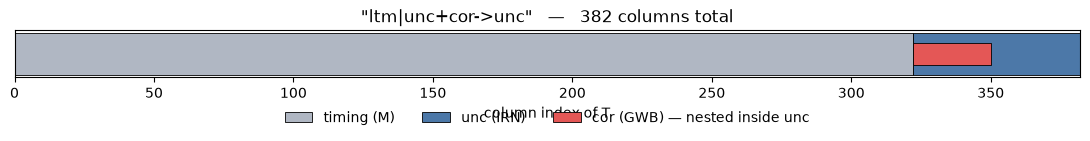

In [14]:
# Visualise the column layout of T.
fig, ax = plt.subplots(figsize=(11, 2.0))
n = rn.nmodes
bands = [("timing (M)",  0, rn.linear_timing_model_size, "#b0b7c3"),
         ("unc (IRN)",   rn.signal_comb_idxs["unc"].start, rn.signal_comb_idxs["unc"].stop, "#4c78a8"),
         ("cor (GWB)",   rn.signal_comb_idxs["cor"].start, rn.signal_comb_idxs["cor"].stop, "#e45756")]
for label, lo, hi, c in bands[:2]:
    ax.barh(0, hi - lo, left=lo, height=0.55, color=c, edgecolor="k", linewidth=.6, label=label)
lo, hi, c = bands[2][1], bands[2][2], bands[2][3]
ax.barh(0.0, hi - lo, left=lo, height=0.28, color=c, edgecolor="k", linewidth=.6,
        label=bands[2][0] + " — nested inside unc")
ax.set_yticks([]); ax.set_xlim(0, n); ax.set_xlabel("column index of T")
ax.set_title(f'"ltm|unc+cor->unc"   —   {n} columns total')
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.45), ncol=3, frameon=False)
plt.tight_layout(); plt.show()

---
# 5. The $\phi$ matrix and the red-noise parameter vector

`SuperSignal.model_maker()` (a method — *not* the NumPyro model function of the same name,
a genuinely confusing name collision in this codebase) builds a `parameterized` object
that turns a **flat parameter vector `xs`** into the prior covariance $\phi$ of the basis
coefficients and its inverse.

Because our model string contains `cor`, ATLAS selects `CorrelatedPulsarRedNoise`; without
it you would get `PerPulsarRedNoise`. The vector layout is

```
[ irn | dm | gtm | gwb_psd | orf ]
```

with the **pulsar index varying slowest** inside each block. `get_param_names()`
reproduces that ordering as strings — always use it to label your posterior samples rather
than assuming an order. Conveniently, those names are exactly the keys used in
`injected_params.json`, so the truth lookup below is a straight dictionary access.

In [15]:
red_names = rn.model.get_param_names()
priors    = rn.model.get_param_names_and_priors()

print(f"{len(red_names)} red-noise parameters\n")
print(f"{'#':>3}  {'name':<28} {'prior':<20} {'injected':>9}")
for i, nm in enumerate(red_names):
    lo, hi = priors[nm]
    print(f"{i:>3}  {nm:<28} U({float(lo):>6.2f}, {float(hi):>6.2f})    {truth[nm]:>9.3f}")

22 red-noise parameters

  #  name                         prior                 injected
  0  B1855+09_irn_log10_A         U(-20.00, -11.00)      -13.900
  1  B1855+09_irn_gamma           U(  0.00,   7.00)        3.300
  2  B1937+21_irn_log10_A         U(-20.00, -11.00)      -13.500
  3  B1937+21_irn_gamma           U(  0.00,   7.00)        3.700
  4  J0030+0451_irn_log10_A       U(-20.00, -11.00)      -14.400
  5  J0030+0451_irn_gamma         U(  0.00,   7.00)        4.700
  6  J1012+5307_irn_log10_A       U(-20.00, -11.00)      -12.600
  7  J1012+5307_irn_gamma         U(  0.00,   7.00)        0.046
  8  J1455-3330_irn_log10_A       U(-20.00, -11.00)      -15.300
  9  J1455-3330_irn_gamma         U(  0.00,   7.00)        1.700
 10  J1643-1224_irn_log10_A       U(-20.00, -11.00)      -12.300
 11  J1643-1224_irn_gamma         U(  0.00,   7.00)        1.500
 12  J1744-1134_irn_log10_A       U(-20.00, -11.00)      -17.300
 13  J1744-1134_irn_gamma         U(  0.00,   7.00)        4.900


Twenty-two red parameters: two per pulsar for the IRN power law, plus two for the GWB.
Note there are **no ORF parameters** — Hellings–Downs is fixed, so `orf_fixed` is true and
the ORF block is absent from the vector. If you swapped in `bin_orf` or `gt_orf` you would
see extra `orf_*` entries appended at the end, and *then* you would need
`lower_bound_orf`/`upper_bound_orf`.

Only the first 14 frequency bins get off-diagonal, ORF-weighted cross-pulsar structure in
$\phi$; bins 14–29 are diagonal and get a cheap reciprocal inverse rather than a Cholesky
(`parameterized.get_phi_mat_inv`). That split is the whole reason a nested `cor` slice is
worth the conceptual awkwardness — and it is a $[14, 10, 10]$ Cholesky here rather than
the $[14, 3, 3]$ of the 3-pulsar notebook.

---
# 6. `helpers` — where all the data goes

Now we compress. `rn.get_helpers` is a **jitted** function built at `SuperSignal`
construction time; which arguments it still expects depends on the run-mode flags we set
on `PTA_Data`. With `fixed_wn=None` and `fixed_res=False` (our case), the basis and the
$N$-matrix handler are already baked in, and it takes:

```python
helpers = rn.get_helpers(reff=<residuals>, white_noise_params=<flat wn vector>)
```

The residuals argument is the **concatenated** 1-D residual vector over all pulsars,
`jnp.concat(data.raw_residuals)`, matching the row-blocking of $T$.

In [16]:
raw_res = jnp.concat(data.raw_residuals)
print("concatenated residual vector:", raw_res.shape,
      f"(= {' + '.join(str(len(r)) for r in data.raw_residuals)})")

t0 = time.time()
helpers = rn.get_helpers(reff=raw_res, white_noise_params=wn_true)
TNT, TNr, rNr, logdet_N = helpers
TNT.block_until_ready()
print(f"built in {time.time() - t0:.1f} s (includes JIT compilation)\n")
print(f"  TNT       {str(TNT.shape):<20} = T^T N^-1 T,  per pulsar")
print(f"  TNr       {str(TNr.shape):<20} = T^T N^-1 r,  per pulsar")
print(f"  rNr       {'scalar':<20} = {float(rNr):.4f}")
print(f"  logdet_N  {'scalar':<20} = {float(logdet_N):.4f}")

concatenated residual vector: (178373,) (= 7758 + 23023 + 19571 + 25837 + 10818 + 22144 + 17745 + 18875 + 18675 + 13927)


built in 12.0 s (includes JIT compilation)

  TNT       (10, 382, 382)       = T^T N^-1 T,  per pulsar
  TNr       (10, 382)            = T^T N^-1 r,  per pulsar
  rNr       scalar               = 70863309.1625
  logdet_N  scalar               = -4581340.3025


That is the entire dataset — 178,373 TOAs — reduced to a $[10, 382, 382]$ array, a
$[10, 382]$ array and two scalars. **Nothing downstream ever sees a TOA again.**

## The cost of varying white noise

Here is the single most important performance fact about a global fit. If white noise is
**fixed**, `helpers` is computed once, right here, outside the sampler, and passed in as a
constant. If white noise is **varied** — as in this notebook — then $N$ changes at every
leapfrog step, so `helpers` must be **rebuilt on every gradient evaluation**, including
the per-epoch Sherman–Morrison solves over all 178,373 TOAs. That is the dominant cost of
the whole analysis.

So `vary_white=True` is a scientific choice with a large, very concrete price. Time it
before you commit to a long run — and time the *gradient*, not just the forward pass,
because that is what NUTS actually calls.

In [17]:
_ = rn.get_helpers(reff=raw_res, white_noise_params=wn_true)[0].block_until_ready()
t0 = time.time()
for _ in range(3):
    _ = rn.get_helpers(reff=raw_res, white_noise_params=wn_true)[0].block_until_ready()
per_call = (time.time() - t0) / 3
print(f"~{per_call*1e3:.0f} ms per helpers rebuild (forward, post-compilation)")

def _logp(theta_wn, xs, z):
    h = rn.get_helpers(reff=raw_res, white_noise_params=theta_wn)
    lp, _ = rn.lnposterior_reparam(helpers=h, red_params=xs, z=z)
    return lp

x_test = jnp.array(sum([[-14.0, 3.2] for _ in data.psr_names], []) + [-14.6, 13/3])
z_zero = jnp.zeros((data.npsrs, rn.nmodes))

grad_fn = jax.jit(jax.grad(_logp, argnums=(0, 1, 2)))
jax.block_until_ready(grad_fn(wn_true, x_test, z_zero))     # compile
t0 = time.time()
for _ in range(3):
    jax.block_until_ready(grad_fn(wn_true, x_test, z_zero))
per_grad = (time.time() - t0) / 3
print(f"~{per_grad*1e3:.0f} ms per full gradient (this is one leapfrog step)")
print(f"-> a NUTS trajectory of 2^5 = 32 leapfrog steps costs ~{per_grad*32:.1f} s")

~63 ms per helpers rebuild (forward, post-compilation)


~145 ms per full gradient (this is one leapfrog step)
-> a NUTS trajectory of 2^5 = 32 leapfrog steps costs ~4.7 s


---
# 7. The standardizing transform

This is the heart of how ATLAS samples, and the thing most worth understanding before you
change anything.

## The problem

Our basis coefficients $a$ — the timing offsets $\epsilon$ *and* the Fourier amplitudes of
IRN and the GWB — are Gaussian with a prior covariance $\phi$ that is itself a function of
the parameters we are trying to infer ($\log_{10}A$, $\gamma$). That is a **hierarchical
funnel**: when the sampled amplitude is small, the coefficients are tightly constrained
near zero; when it is large, they range widely. The posterior is a narrow neck opening
into a wide mouth. HMC cannot choose a single step size that works in both regions — it
either rejects constantly in the neck or crawls in the mouth. This is exactly Neal's
funnel, and it is fatal at these dimensions.

## The fix: sample a standardized variable instead

Given the data-side precision $T^{\mathsf T}N^{-1}T$ and the prior precision $\phi^{-1}$,
the **conditional posterior of the coefficients is exactly Gaussian**:

$$
\Sigma^{-1} = T^{\mathsf T} N^{-1} T + \phi^{-1},
\qquad
\hat a = \Sigma\, T^{\mathsf T} N^{-1} r ,
\qquad
a \mid \theta \sim \mathcal N(\hat a, \Sigma).
$$

So rather than sampling $a$ directly, ATLAS samples a standard normal variable
$z \sim \mathcal N(0, I)$ and *deterministically maps* it through the conditional
posterior. Taking the Cholesky $\Sigma^{-1} = LL^{\mathsf T}$:

$$
\boxed{\;a = \hat a + L^{-\mathsf T} z\;}
$$

Check that this is right: $\operatorname{Cov}(a) = L^{-\mathsf T} L^{-1} =
(L L^{\mathsf T})^{-1} = \Sigma$. ✓

The change of variables contributes a Jacobian
$\left|\partial a / \partial z\right| = \left|L^{-\mathsf T}\right|$, hence

$$
\log\left|\det \frac{\partial a}{\partial z}\right| = -\sum_i \log L_{ii}.
$$

The point is that the *conditional* geometry in $z$ is now **exactly unit-normal at every
value of the spectral parameters**. The funnel between a spectrum and the coefficients it
governs has been absorbed into the deterministic map, so a single step size works
everywhere along the amplitude axis. (The joint posterior still has curvature coupling
$\theta$ and $z$ — this is not a free lunch, it is a *reparameterisation* — but the
pathological part of the geometry is gone.) This is why it is called a *standardizing*,
or non-centered, transform.

In `factorized/base.py` this is a handful of lines (`lnposterior_reparam`, ~line 1240):

```python
Sigma_inv   = TNT.at[:, diag, diag].add(phiinvs_diags.T)      # T^T N^-1 T + phi^-1
Sigma_inv_L = jsl.cho_factor(Sigma_inv, lower=True)           # L
a_hat       = jsl.cho_solve(Sigma_inv_L, TNr[..., None])      # MAP coefficients
Lz          = triangular_solve(Sigma_inv_L[0], z[..., None],  # L^-T z
                               left_side=True, lower=True, transpose_a=True)
coeff       = a_hat + Lz
lndet_Jac   = -jnp.sum(jnp.log(Sigma_inv_L[0].diagonal(axis1=-2, axis2=-1)))
```

## Where the linear timing model enters

For the timing columns, `phiinvs_diags` is set to `lowest_value_eq_to_zero = 1e-40` —
numerically a flat prior on $\epsilon$, but **present in the geometry** so that
$\Sigma^{-1}$ is well defined and NUTS has a finite gradient to follow. The padded dummy
columns instead get prior precision 1 and their own $-\tfrac12\sum(\text{pad} \cdot a)^2$
term. Both behaviours are switched on by `linear_timing and not marg_tm` — i.e. exactly
the mode we selected in §2.

Let us verify the identity numerically.

In [18]:
# Evaluate the log posterior once, at the initialisation point we will use for NUTS.
lp, coeff = rn.lnposterior_reparam(helpers=helpers, red_params=x_test, z=z_zero)
print("log posterior at z = 0 :", float(lp))
print("coefficients          :", coeff.shape, " [npsr, nmodes]")
print("with z = 0 the coefficients are exactly the MAP vector a_hat")

log posterior at z = 0 : 2161037.259193003
coefficients          : (10, 382)  [npsr, nmodes]
with z = 0 the coefficients are exactly the MAP vector a_hat


In [19]:
# Verify Cov(a) = Sigma for one pulsar, directly from the transform.
import jax.scipy.linalg as jsl

phi_full = rn.model.get_phi_mat_full(x_test)
phiinvs, _ = rn.model.get_phi_mat_inv(phi_full)
phiinv_diag = phiinvs.diagonal(axis1=-2, axis2=-1)          # [nmodes_red, npsr]

# rebuild the timing-column padding exactly as lnposterior_reparam does
ltm = rn.linear_timing_model_size
pd = jnp.full((rn.nmodes, data.npsrs), rn.lowest_value_eq_to_zero)
pd = pd.at[ltm:, :].add(phiinv_diag)
pd = pd.at[:ltm, :].add(rn._pad_mask.T)

Sigma_inv = TNT.at[:, rn._diag_idx, rn._diag_idx].add(pd.T)
p = 0
L = jnp.linalg.cholesky(Sigma_inv[p])                        # lower
Linv_T = jnp.linalg.inv(L).T                                 # L^-T
cov_from_transform = Linv_T @ Linv_T.T                       # L^-T L^-1
Sigma_direct = jnp.linalg.inv(Sigma_inv[p])

err = float(jnp.max(jnp.abs(cov_from_transform - Sigma_direct)) /
            jnp.max(jnp.abs(Sigma_direct)))
print(f"max relative difference between L^-T L^-1 and Sigma : {err:.2e}")
print("log|det da/dz| = -sum(log diag L) =", float(-jnp.sum(jnp.log(jnp.diag(L)))))

max relative difference between L^-T L^-1 and Sigma : 3.27e-22
log|det da/dz| = -sum(log diag L) = -3255.501381317406


## The cost: dimensionality

The price of making every coefficient explicit is that **all of them are sampled**. Here:

In [20]:
n_latent = data.npsrs * rn.nmodes
print(f"z_a latent dimensions : {data.npsrs} x {rn.nmodes} = {n_latent}")
print(f"red-noise parameters  : {len(red_names)}")
print(f"white-noise parameters: {len(wn_names)}")
print(f"TOTAL sampled dimension: {n_latent + len(red_names) + len(wn_names)}")

z_a latent dimensions : 10 x 382 = 3820
red-noise parameters  : 22
white-noise parameters: 141
TOTAL sampled dimension: 3983


3,820 latent coefficients for ten pulsars — of which 1,019 are the dummy padding columns
counted in §4, i.e. **more than a quarter of the latent space is pure padding**. That
fraction grows with array heterogeneity, and it is one of the two reasons the full
67-pulsar array with an Adaptus basis reaches ~37,600 latent dimensions.

For that regime ATLAS offers `partial_marg_lnposterior`, a third likelihood that
analytically marginalises the per-pulsar block (timing + IRN + Adaptus) via a Schur
complement and keeps only the GWB coefficients explicit, dropping ~37,600 latent
dimensions to ~1,876. You select it with `marg_over_non_gwb=True`.

**We do not use it here**, for two reasons. First, at ten pulsars the full
parameterisation is still tractable. Second — and this would bite you —
`partial_marg_lnposterior_helper` unconditionally indexes
`signal_comb_idxs['timing']`, `['unc']` **and** `['gtm']`, so a model string without a
`gtm` component (like ours) raises `KeyError: 'gtm'` rather than marginalising over
whichever non-GWB blocks actually exist. If you want partial marginalisation, you
currently need an Adaptus basis in the model too.

---
# 8. The NumPyro model

`ATLAS.samplers.canetoadracing.model_maker` is the actual NumPyro model of the whole PTA.
(It is somewhat buried: it lives at the bottom of a file whose first 675 lines are a
vendored copy of Coleman Krawczyk's `MultiHMCGibbs` sampler.) Let us just read it.

In [21]:
print(inspect.getsource(model_maker))

def model_maker(raw_residuals, 
                super_sig,
                marg_over_non_gwb,
                vary_white = False,
                wn_lower_bound = None,
                wn_upper_bound = None,
                tm_model = None,
                helpers = None,
                save_red_coeff = False,
                fixed_white_noise_params = None,
                ):
                
    ######################################## Timing Model ########################################
    if tm_model:
        lam = numpyro.sample("timing_lam", dist.HalfNormal(10.0))
        k = numpyro.sample("timing_k", dist.Normal(0, 50).expand([tm_model.nparams_total]))
        stochastic_res = tm_model.residuals(k * lam)
    else:
        stochastic_res = raw_residuals

    ######################################## White Noise ########################################
    if vary_white:
        theta_wn = numpyro.sample('white_noise', dist.Uniform(wn_lower_bound, wn_upper_bound))
        helpe

Walking through it for **our** configuration:

1. **Timing model.** `tm_model=None`, so `stochastic_res = raw_residuals`. (The `tm_model`
   branch is philosophy (c), the nonlinear JUG path — not ours.)

2. **White noise.** `vary_white=True`, so
   ```python
   theta_wn = numpyro.sample('white_noise', dist.Uniform(wn_lower_bound, wn_upper_bound))
   helpers_now = super_sig.get_helpers(reff=stochastic_res, white_noise_params=theta_wn)
   ```
   The `helpers` we built in §6 are **ignored** — they are rebuilt from the sampled
   white-noise vector every single gradient evaluation. Note also that this path puts a
   **uniform** prior on EFAC, taken from the bounds we set. `SinglePulsarWhiteCov` also
   offers `make_numpyro_prior()`, which gives each backend a *named* site and a truncated-
   normal EFAC prior centred on 1 — which is in fact exactly the distribution the EFACs
   were drawn from when this dataset was made — but `model_maker` does not use it. If you
   want that prior, write your own model function.

3. **Red noise.**
   ```python
   xs = numpyro.sample('red_noise', dist.Uniform(model.lower_prior_lim_all,
                                                 model.upper_prior_lim_all))
   ```
   i.e. exactly the uniform prior ranges we tabulated in §5, in the `get_param_names()`
   order.

4. **Coefficients and the likelihood.** With `marg_over_non_gwb=False`:
   ```python
   z_a = numpyro.sample('z_a', dist.Normal(0, 1).expand((npsrs, nmodes)))
   lprob, coeff = super_sig.lnposterior_reparam(helpers=helpers_now, red_params=xs, z=z_a)
   ```

5. **The correction term you must not delete.**
   ```python
   numpyro.factor('lnpost', lprob + 0.5 * jnp.sum(z_a**2))
   ```
   `lprob` returned by `lnposterior_reparam` is the *complete* log posterior in
   coefficient space — it already contains the exact Gaussian prior on $a$ **and** the
   Jacobian $-\sum_i \log L_{ii}$. But NumPyro has separately already added
   $\log \mathcal N(z; 0, I) = -\tfrac12\sum z^2 + \text{const}$ for the `z_a` site.
   Adding $+\tfrac12\sum z^2$ back cancels that double-count exactly, leaving `lprob`
   (up to an irrelevant constant). **Remove this term and your posterior is silently
   wrong** — it will still run, still look plausible, and give you the wrong answer.

---
# 9. Initialisation

NUTS initialised from a random draw of these priors will start with EFACs anywhere in
$(0.01, 10)$ and red-noise amplitudes anywhere over nine decades — a place where the
likelihood is astronomically bad and warmup may never recover.

Initialise deliberately with `init_to_value`:

* **white noise** at the injected values,
* **red noise** at plausible generic values ($\log_{10}A \approx -14$, $\gamma \approx 3.2$
  for IRN; the 15 yr GWB result $\log_{10}A \approx -14.6$, $\gamma = 13/3$),
* **`z_a` at zero**, which by the transform above starts every coefficient exactly at its
  MAP value $\hat a$ — the best possible starting point.

> **Be honest about what this means.** Starting white noise *at the truth* is the
> simulated-data analogue of the 3-pulsar notebook starting at the published NG15 values,
> and it is fine for a pipeline demonstration — but it means the white-noise posteriors in
> §12 test whether the sampler *stays* in a good region, not whether it can *find* one. For
> a blind test, initialise from `wn.prior_draw()` or from an Enterprise white-noise fit,
> and budget several hundred more warmup iterations. The red-noise initialisation is not
> at the truth: the per-pulsar IRN starts at $-14$ regardless of whether the injected value
> was $-12.3$ or $-18.6$.

In [22]:
rn_init = []
for _ in data.psr_names:
    rn_init += [-14.0, 3.2]        # per-pulsar IRN: log10_A, gamma
rn_init += [-14.6, 13/3]           # GWB: log10_A, gamma
rn_init = jnp.array(rn_init)
assert len(rn_init) == len(red_names)

init_values = {
    "white_noise": wn_true,
    "red_noise":   rn_init,
    "z_a":         jnp.zeros((data.npsrs, rn.nmodes)),
}
for k, v in init_values.items():
    print(f"{k:<12} {v.shape}")

white_noise  (141,)
red_noise    (22,)
z_a          (10, 382)


---
# 10. Running NUTS

A few notes on the settings:

* `target_accept_prob=0.8` is the NumPyro default and is usually fine here; raise it to
  0.9 if you see divergences.
* `max_tree_depth` caps the trajectory at $2^{d}$ leapfrog steps. **With
  `vary_white=True` each of those steps rebuilds `helpers`**, so this parameter directly
  multiplies your wall-clock cost. Do the arithmetic with the per-gradient time measured
  in §6 before you launch: at ~150 ms/gradient on the GPU this was run on,
  `max_tree_depth=5` means up to 31 steps ≈ 4.3 s per iteration, and `max_tree_depth=7`
  would be four times that. **Expect the reported `num_steps` below to sit at 31, i.e.
  pinned to the cap** — this posterior wants longer trajectories than we are paying for,
  which costs mixing efficiency per iteration. That is a deliberate trade for a
  demonstration run; if you raise the cap, watch the pool ceiling from §0, because a
  deeper tree is also what triggers compilation of the largest executable.
* NumPyro stores every sample site, and `z_a` is $[10, 382]$ per sample — for 1000 samples
  that is ~3.8M floats. Expect the output to be dominated by coefficients, not parameters.
* On CPU this same run is roughly an order of magnitude slower. ATLAS keeps the per-pulsar
  arrays batched precisely so that a GPU can be used, and at ten pulsars that stops being
  a nicety.

The settings below take roughly 110 minutes on a single RTX 4090. An earlier version of
this notebook used `num_warmup=150, num_samples=300` — a third of the cost — and the trace
plots in §12 showed the GWB amplitude still sliding monotonically downwards through the
whole sampling phase. That is the failure mode to watch for here: a 3,983-dimensional
posterior sampled with trajectories pinned at 31 leapfrog steps takes a while to reach its
typical set, and a short chain reports the transient rather than the posterior. Even at
these settings this is a demonstration, **not** a converged run: for a real analysis raise
`num_samples` to ~3000, run several chains, and check $\hat R$.

In [23]:
NUM_WARMUP  = 500     # <-- 500 is the minimum that gets this chain out of its transient
NUM_SAMPLES = 1000    # <-- raise to ~3000 for a real run

nuts_kernel = NUTS(
    model              = model_maker,
    target_accept_prob = 0.8,
    max_tree_depth     = 5,     # <-- see the cost note above before raising this
    init_strategy      = init_to_value(values=init_values),
)

mcmc = MCMC(nuts_kernel, num_warmup=NUM_WARMUP, num_samples=NUM_SAMPLES, num_chains=1)

t0 = time.time()
mcmc.run(
    jrandom.key(170817),
    raw_residuals    = raw_res,
    super_sig        = rn,
    vary_white       = True,            # <-- rebuild helpers every leapfrog step
    wn_lower_bound   = wn_lower_bound,
    wn_upper_bound   = wn_upper_bound,
    tm_model         = None,            # not using the nonlinear JUG timing model
    helpers          = None,            # ignored when vary_white=True
    save_red_coeff   = False,           # set True to also store the coefficient vector
    marg_over_non_gwb = False,          # full lnposterior_reparam
    extra_fields     = ("diverging", "num_steps"),
)
print(f"\nfinished in {(time.time() - t0)/60:.1f} min")


  0%|          | 0/1500 [00:00<?, ?it/s]


  0%|          | 0/1500 [00:18<?, ?it/s]


warmup:   0%|          | 1/1500 [00:20<8:41:09, 20.86s/it, 1 steps of size 2.34e+00. acc. prob=0.00]


warmup:   0%|          | 2/1500 [00:21<3:36:46,  8.68s/it, 1 steps of size 2.30e-01. acc. prob=0.00]


warmup:   0%|          | 3/1500 [00:21<1:59:21,  4.78s/it, 1 steps of size 1.67e-02. acc. prob=0.00]

...


sample: 100%|█████████▉| 1498/1500 [1:46:37<00:08,  4.35s/it, 31 steps of size 1.00e-02. acc. prob=0.95]


sample: 100%|█████████▉| 1499/1500 [1:46:41<00:04,  4.35s/it, 31 steps of size 1.00e-02. acc. prob=0.95]


sample: 100%|██████████| 1500/1500 [1:46:46<00:00,  4.35s/it, 31 steps of size 1.00e-02. acc. prob=0.95]


sample: 100%|██████████| 1500/1500 [1:46:46<00:00,  4.27s/it, 31 steps of size 1.00e-02. acc. prob=0.95]


finished in 107.1 min


In [24]:
samples = mcmc.get_samples()
extra   = mcmc.get_extra_fields()

for k, v in samples.items():
    print(f"{k:<12} {v.shape}")
print()
print("divergences        :", int(np.asarray(extra['diverging']).sum()), "/", NUM_SAMPLES)
print("mean leapfrog steps:", float(np.asarray(extra['num_steps']).mean()))
print("max  leapfrog steps:", int(np.asarray(extra['num_steps']).max()), "(cap is 2^5 - 1 = 31)")

red_noise    (1000, 22)
white_noise  (1000, 141)
z_a          (1000, 10, 382)

divergences        : 0 / 1000
mean leapfrog steps: 31.0
max  leapfrog steps: 31 (cap is 2^5 - 1 = 31)


---
# 11. How many independent samples is this? (read before §12)

`num_samples=1000` is not 1000 pieces of information. Compute the effective sample size
and the split-$\hat R$ *before* looking at any posterior, because at this array size they
determine whether the numbers below mean anything.

`numpyro.diagnostics.summary` gives both. $\tau = N/\mathrm{ESS}$ is the integrated
autocorrelation time — how many iterations the chain needs to produce one quasi-independent
draw.

In [25]:
from numpyro.diagnostics import summary

def diagnose(arr, names=None, label=""):
    """ESS / tau / split-Rhat for an [nsamples, ...] array of samples."""
    s = summary({"x": np.asarray(arr)[None, ...]}, group_by_chain=True)["x"]
    ess = np.asarray(s["n_eff"]).ravel(); rhat = np.asarray(s["r_hat"]).ravel()
    if names is not None:
        print(f"{'parameter':<28} {'ESS':>7} {'tau=N/ESS':>10} {'split-Rhat':>11}")
        for i, nm in enumerate(names):
            print(f"{nm:<28} {ess[i]:>7.1f} {NUM_SAMPLES/ess[i]:>10.1f} {rhat[i]:>11.3f}"
                  f"{'   <-- not converged' if rhat[i] > 1.05 else ''}")
    else:
        print(f"{label}: {ess.size} parameters")
        print(f"   ESS  min {ess.min():>6.1f} | median {np.median(ess):>6.1f} | max {ess.max():>6.1f}")
        print(f"   Rhat max {rhat.max():>6.3f} | median {np.median(rhat):>6.3f} | "
              f"#(Rhat>1.05) {int((rhat > 1.05).sum())} of {rhat.size}")
    return ess, rhat

ess_red, _ = diagnose(np.asarray(samples["red_noise"]), red_names)
print()
diagnose(np.asarray(samples["white_noise"]), None, "white noise")
diagnose(np.asarray(samples["z_a"]).reshape(NUM_SAMPLES, -1), None, "z_a coefficients")

_g = ess_red[list(red_names).index("gwb_log10_A")]
print(f"\nGWB amplitude: {_g:.1f} effective samples from {NUM_SAMPLES} draws")
print(f"MCSE on its mean = sd/sqrt(ESS) = {np.asarray(samples['red_noise'])[:, -2].std()/np.sqrt(_g):.2f} dex")

parameter                        ESS  tau=N/ESS  split-Rhat
B1855+09_irn_log10_A            11.2       89.5       1.174   <-- not converged
B1855+09_irn_gamma               8.3      120.3       1.071   <-- not converged
B1937+21_irn_log10_A            29.3       34.2       1.018
B1937+21_irn_gamma               9.4      106.7       1.049
J0030+0451_irn_log10_A          19.0       52.7       1.023
J0030+0451_irn_gamma            20.7       48.3       1.028
J1012+5307_irn_log10_A          12.7       78.9       1.002
J1012+5307_irn_gamma            13.4       74.8       1.059   <-- not converged
J1455-3330_irn_log10_A           6.3      158.4       1.394   <-- not converged
J1455-3330_irn_gamma             7.9      127.1       1.569   <-- not converged
J1643-1224_irn_log10_A           9.5      105.4       1.007
J1643-1224_irn_gamma            11.9       84.0       1.012
J1744-1134_irn_log10_A          37.2       26.9       1.025
J1744-1134_irn_gamma             8.4      118.7       1.200 

z_a coefficients: 3820 parameters
   ESS  min    2.8 | median   11.1 | max   44.5
   Rhat max  4.004 | median  1.070 | #(Rhat>1.05) 2164 of 3820

GWB amplitude: 8.6 effective samples from 1000 draws
MCSE on its mean = sd/sqrt(ESS) = 0.15 dex


Those numbers are the honest headline of this notebook, and they are sobering. In the run
above, the GWB amplitude has **ESS ≈ 9 out of 1000 draws** ($\tau \approx 117$), the worst
red parameter has ESS 3.5 at $\hat R = 2.4$, 75 of the 141 white-noise parameters and
**2,164 of the 3,820** latent coefficients have $\hat R > 1.05$ (worst 4.0). That is about
twelve minutes of GPU per quasi-independent sample of the one number we are after.

There is a sharper way to see it. This exact configuration has now been run **three times —
same seed, same settings**, differing only in GPU floating-point reduction order — and the
GWB posterior mean came out $-16.24$, $-15.04$ and $-15.21$. The spread is 1.21 dex, the
three-chain $\hat R$ is **1.36**, and the scatter between chain means (0.65 dex) is four
times the within-chain MCSE that each run reports for itself (~0.15 dex). Bitwise
nondeterminism moves the answer by far more than the error bar the chain claims.

**So: the qualitative conclusion in §12 (an upper limit, not a detection, because the loud
IRN pulsars swamp the GWB) is robust. The digits are not.** Never quote an interval from a
chain like this without ESS and $\hat R$ beside it, and prefer several chains from
different initialisations over one long one.

## What actually fixes it

The cost and the mixing are both dominated by one choice — `vary_white=True`. Measured on
this exact configuration:

| configuration | gradient | s/iter @31 | ESS/1000 (GWB) | s per effective sample |
|---|---|---|---|---|
| this notebook (vary WN) | 145 ms | 4.51 s | 14.5 | **445** |
| white noise **fixed** | 7.7 ms | 0.23 s | **166** | **2.0** |

Fixing white noise is ~20× cheaper per gradient *and* ~11× better mixing per iteration:
about 220× more effective samples per second, with $\hat R\approx1.00$ and 0–1 divergences.
The 141 white-noise parameters are coupled to everything through $N$, and sampling them
jointly with 3,820 coefficients is what wrecks the geometry.

But that row is honest about cost and unfair about inference: with white noise **fixed** you
are sampling a *different*, conditional posterior, and you have thrown away exactly the
uncertainty propagation that motivates a global fit. The same-target fix is to give white
noise its own Gibbs block. Measured on a matched 5-pulsar subset (same seed, same tree
depth, 200 warmup + 400 samples, so all three rows are comparable to each other):

| scheme | GWB ESS / 400 | s / iteration | split-$\hat R$ | ESS / iteration | end-to-end |
|---|---|---|---|---|---|
| one joint NUTS (this notebook) | 7.2 | 2.28 | 1.049 | 0.018 | 1.0× |
| `MultiHMCGibbs`, white noise blocked | **64.4** | 3.50 | **0.999** | **0.161** | **5.9×** |
| white noise fixed (*different target*) | 218.4 | 0.19 | 1.014 | 0.546 | 366× |

```python
from ATLAS.samplers.canetoadracing import MultiHMCGibbs
kernel = MultiHMCGibbs(
    [NUTS(model_maker, max_tree_depth=5, init_strategy=init),
     NUTS(model_maker, max_tree_depth=5, init_strategy=init)],
    [["white_noise"], ["red_noise", "z_a"]],   # partition must cover every site exactly once
    num_steps=[1, 1],                          # run the red block N times per WN update
)
```

Blocking buys a **9× improvement in mixing per iteration for a 1.5× increase in cost per
sweep**, while still varying white noise. And look at where the three schemes land: the
joint chain reports $\log_{10}A = -16.99 \pm 1.18$ from 7 effective samples; the Gibbs chain
reports $-15.36 \pm 1.34$ from 64. **Better mixing moved the answer 1.6 dex towards the
injected $-14.62$** — most of the very low amplitude in the badly-mixed chain was a sampling
artefact, not evidence.

Two things to know before tuning it. First, `MultiHMCGibbs` partitions by *site name*, and
`white_noise` is a single 141-element site, so the whole array's white noise moves in one
transition; per-pulsar blocking would need a model built on
`SinglePulsarWhiteCov.make_numpyro_prior()`, which emits one site per backend. Second,
raising `num_steps=[1, N]` helps less than you would hope *with this model*, because
`model_maker` rebuilds `helpers` on every gradient whether or not white noise is free — so
the cheap-looking red block costs the same as the expensive one. With the measured
$c_\mathrm{wn}=1.22$ s, $c_\mathrm{red}=2.28$ s and 0.161 ESS per red transition, $N=1$ gives
21.7 s per effective sample and $N\to\infty$ only reaches 14.2. Feed the red block
precomputed `helpers` (0.19 s) and the same knob reaches ~1.9 s at $N=10$ — that is where
the remaining order of magnitude lives.

Two things that do **not** work, both measured rather than assumed:

* **Raising `max_tree_depth`.** At depth 6, 100% of sampling iterations still hit the cap
  (63 steps, 8.6 s/iter). The trajectories are truncated at every depth we can afford, which
  says the geometry is bad — not that the tuning is wrong.
* **`marg_over_non_gwb=True`.** Making the Schur complement well-posed requires `cor` to
  have its own basis block (`"ltm|unc;cor"`), and those 28 GWB columns are then bit-for-bit
  identical to the first 28 IRN columns — $T$ has rank 382 of 410. The sampler froze: step
  size $1.1\times10^{-12}$, posterior sd $0.000$, ESS 4. Partial marginalisation is built for
  a block that spans *different* functions from the GWB (the Adaptus `gtm` basis); it cannot
  absorb the IRN, because the IRN shares the GWB's basis by construction.

---
# 12. Looking at the results

The `red_noise` samples are a bare `[nsamples, 22]` array — **use
`rn.model.get_param_names()` to label the columns**, never a hand-written ordering.
Likewise `wn.get_param_names()` for the white noise. Because those names are the keys of
`injected_params.json`, every table and plot below can carry its truth alongside.

In [26]:
red_chain = np.asarray(samples["red_noise"])
wn_chain  = np.asarray(samples["white_noise"])

red_df = {nm: red_chain[:, i] for i, nm in enumerate(red_names)}
wn_df  = {nm: wn_chain[:, i]  for i, nm in enumerate(wn_names)}

print(f"{'parameter':<28} {'injected':>9} {'mean':>8} {'std':>8} {'16%':>8} {'84%':>8}")
for nm, v in red_df.items():
    q16, q84 = np.percentile(v, [16, 84])
    print(f"{nm:<28} {truth[nm]:>9.2f} {v.mean():>8.3f} {v.std():>8.3f} {q16:>8.3f} {q84:>8.3f}")

parameter                     injected     mean      std      16%      84%
B1855+09_irn_log10_A            -13.90  -16.606    1.490  -18.041  -15.367
B1855+09_irn_gamma                3.30    3.892    1.944    1.470    6.137
B1937+21_irn_log10_A            -13.50  -13.375    0.050  -13.424  -13.322
B1937+21_irn_gamma                3.70    3.291    0.221    3.051    3.501
J0030+0451_irn_log10_A          -14.40  -13.200    0.260  -13.467  -12.954
J0030+0451_irn_gamma              4.70    2.683    0.634    2.075    3.296
J1012+5307_irn_log10_A          -12.60  -12.646    0.038  -12.689  -12.605
J1012+5307_irn_gamma              0.05    0.410    0.245    0.165    0.659
J1455-3330_irn_log10_A          -15.30  -15.393    1.722  -17.300  -13.492
J1455-3330_irn_gamma              1.70    2.005    1.496    0.521    3.651
J1643-1224_irn_log10_A          -12.30  -12.266    0.062  -12.334  -12.204
J1643-1224_irn_gamma              1.50    1.648    0.277    1.350    1.904
J1744-1134_irn_log10_A   

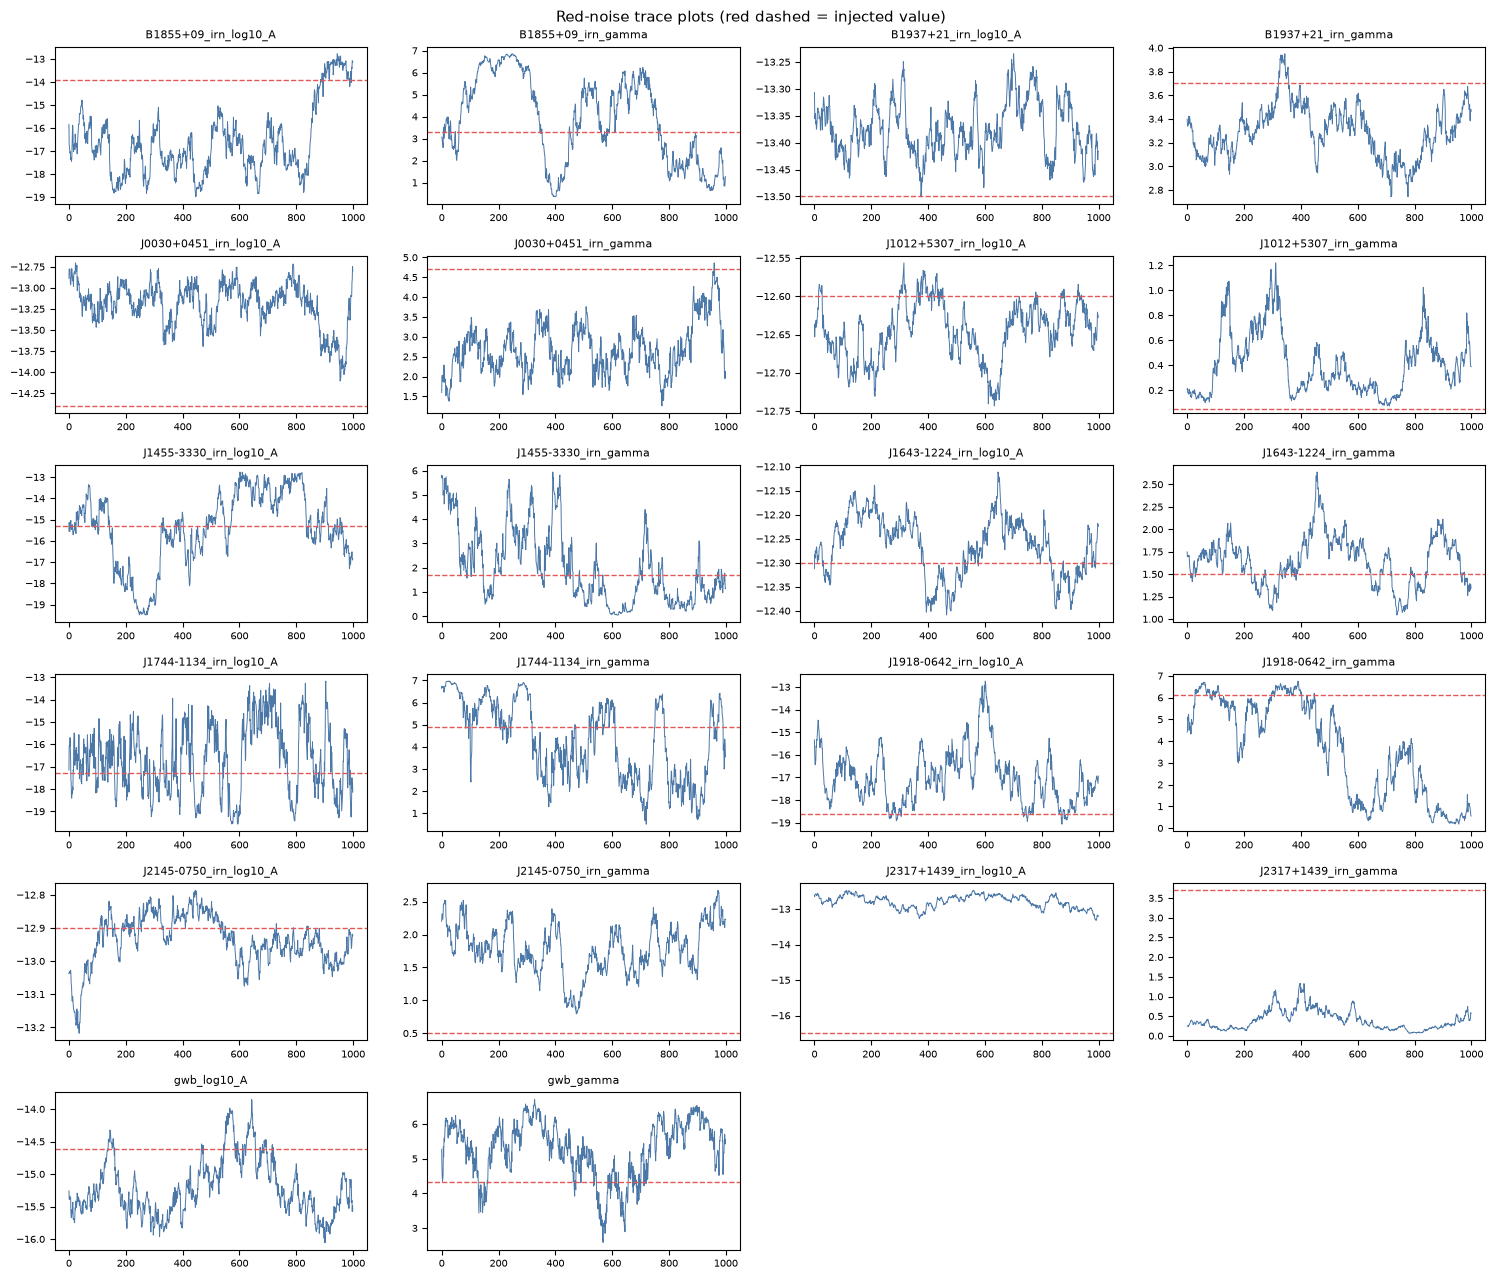

In [27]:
fig, axes = plt.subplots(6, 4, figsize=(15, 13))
for ax, nm in zip(axes.ravel(), red_names):
    v = red_df[nm]
    ax.plot(v, lw=.7, color="#4c78a8")
    ax.axhline(truth[nm], color="#e45756", ls="--", lw=1)
    ax.set_title(nm, fontsize=8)
    ax.tick_params(labelsize=7)
for ax in axes.ravel()[len(red_names):]:
    ax.axis("off")
fig.suptitle("Red-noise trace plots (red dashed = injected value)", fontsize=11)
plt.tight_layout(); plt.show()

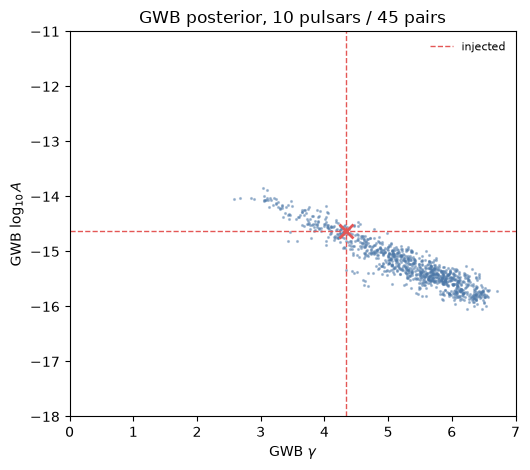

gwb_log10_A = -15.31 (+0.58 / -0.32)    injected -14.62
gwb_gamma   = 5.41 (+0.67 / -1.05)    injected 4.33


In [28]:
# The GWB 2-D posterior -- the plot everyone actually wants.
fig, ax = plt.subplots(figsize=(5.4, 4.8))
ax.plot(red_df["gwb_gamma"], red_df["gwb_log10_A"], ".", ms=2.5, alpha=.4, color="#4c78a8")
ax.axhline(truth["gwb_log10_A"], ls="--", lw=1, color="#e45756", label="injected")
ax.axvline(truth["gwb_gamma"],   ls="--", lw=1, color="#e45756")
ax.plot(truth["gwb_gamma"], truth["gwb_log10_A"], "x", ms=10, mew=2, color="#e45756")
ax.set_xlabel(r"GWB $\gamma$"); ax.set_ylabel(r"GWB $\log_{10}A$")
ax.set_xlim(0, 7); ax.set_ylim(-18, -11)
ax.set_title("GWB posterior, 10 pulsars / 45 pairs")
ax.legend(fontsize=8, frameon=False)
plt.tight_layout(); plt.show()

q = np.percentile(red_df["gwb_log10_A"], [16, 50, 84])
print(f"gwb_log10_A = {q[1]:.2f} (+{q[2]-q[1]:.2f} / -{q[1]-q[0]:.2f})    injected {truth['gwb_log10_A']:.2f}")
q = np.percentile(red_df["gwb_gamma"], [16, 50, 84])
print(f"gwb_gamma   = {q[1]:.2f} (+{q[2]-q[1]:.2f} / -{q[1]-q[0]:.2f})    injected {truth['gwb_gamma']:.2f}")

Ten pulsars give 45 pairs, which is enough angular coverage for a Hellings–Downs
correlation to be identifiable in principle — the qualitative difference from the 3-pulsar
notebook, where 3 pairs could not distinguish a correlated background from three
independent red-noise processes at all. But look at what actually came out:

$$\log_{10}A_\mathrm{GWB} = -15.31^{+0.58}_{-0.32}\quad\text{against an injected } -14.62,$$

with $\gamma$ pushed high and poorly constrained. **The injected background is not
recovered** — and per §11 that interval carries ~9 effective samples, so read it as an
order-of-magnitude statement, not a measurement. Across the three runs of this notebook the
same quantity moved between $-16.24$ and $-15.04$.

That is the correct answer for this sub-array, and the reason is already visible in the
table in §1. Selecting pulsars by baseline length picked up six whose *injected* intrinsic
red noise is at or above the injected GWB level, and three of those — J1643-1224 at
$-12.3$, J1012+5307 at $-12.6$, J2145-0750 at $-12.9$ — sit one and a half to two decades
above it. A common process is absorbable into per-pulsar processes, and here the per-pulsar
processes were injected loud enough to swallow it. NANOGrav's 15 yr detection came from 67
pulsars, most of them far quieter than these ten.

Two things to take from this, rather than "the pipeline is broken":

1. **Sub-array selection is a scientific choice, not a convenience.** Baseline length is
   the right criterion for *frequency coverage* and the wrong one for *sensitivity to a
   common signal*. Re-running this notebook with ten pulsars chosen for low injected IRN is
   a two-line edit in §1 and is the single most instructive experiment you can do with it.
2. **Read the traces, and §11, before you quote an interval.** The GWB parameters wander
   over much of their prior range on a scale of hundreds of samples, and individual pulsars
   get stuck in modes for hundreds of iterations at a time. At 3,983 dimensions with every
   trajectory pinned to the tree-depth cap, 1,000 samples buys ~9 independent ones.

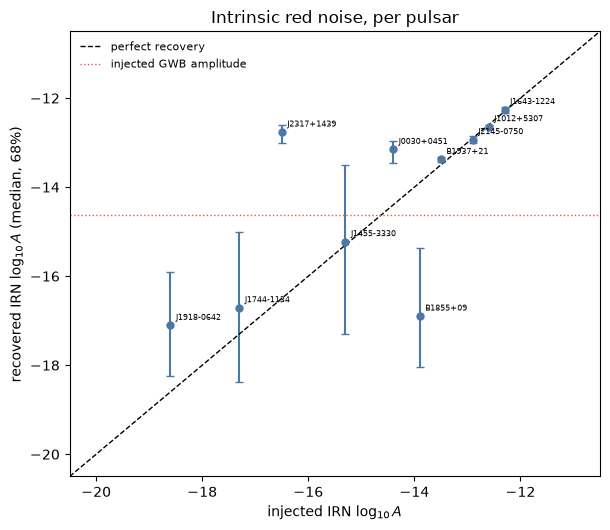

In [29]:
# Per-pulsar IRN: recovered vs injected. Amplitude only -- gamma is meaningless where the
# amplitude is unconstrained.
inj  = np.array([truth[f"{n}_irn_log10_A"] for n in data.psr_names])
med  = np.array([np.median(red_df[f"{n}_irn_log10_A"]) for n in data.psr_names])
lo   = np.array([np.percentile(red_df[f"{n}_irn_log10_A"], 16) for n in data.psr_names])
hi   = np.array([np.percentile(red_df[f"{n}_irn_log10_A"], 84) for n in data.psr_names])

fig, ax = plt.subplots(figsize=(6.2, 5.4))
ax.errorbar(inj, med, yerr=[med - lo, hi - med], fmt="o", ms=5, capsize=3, color="#4c78a8")
lims = (-20.5, -10.5)
ax.plot(lims, lims, "k--", lw=1, label="perfect recovery")
ax.axhline(truth["gwb_log10_A"], color="#e45756", ls=":", lw=1,
           label="injected GWB amplitude")
for x, y, n in zip(inj, med, data.psr_names):
    ax.annotate(n, (x, y), fontsize=6, xytext=(4, 4), textcoords="offset points")
ax.set_xlim(*lims); ax.set_ylim(*lims)
ax.set_xlabel(r"injected IRN $\log_{10}A$"); ax.set_ylabel(r"recovered IRN $\log_{10}A$ (median, 68%)")
ax.set_title("Intrinsic red noise, per pulsar")
ax.legend(fontsize=8, frameon=False)
plt.tight_layout(); plt.show()

Split the plot at the dotted line, which marks the injected GWB amplitude.

* **The loud pulsars are recovered precisely.** J1643-1224 ($-12.27$ vs $-12.30$),
  J1012+5307 ($-12.65$ vs $-12.60$), J2145-0750 ($-12.94$ vs $-12.90$) and B1937+21
  ($-13.38$ vs $-13.50$) land on the diagonal to within 0.13 dex, with 68% intervals barely
  wider than the marker — and these are the four with ESS above ~10 in §11. Where there is
  signal *and* the sampler moves, this pipeline measures it.
* **J0030+0451 is recovered 1.2 dex high** ($-14.40$ injected, $-13.20$ recovered) with a
  tight interval and $\gamma$ pulled from 4.7 down to 2.7. Its injected IRN sits essentially
  at the GWB level, exactly where the common/individual degeneracy is worst. This is the
  clearest sign of common power being absorbed into a per-pulsar spectrum, and it is the
  mechanism behind the low GWB posterior above.
* **J2317+1439 sits 3.7 dex high** ($-12.79$ vs $-16.50$) with $\gamma \to 0.4$, i.e. a flat,
  loud "red" component standing in for something broadband. Its ESS is 10 and its trace is
  visibly mode-locked; treat the interval as a description of where the chain spent its
  time.
* **The quiet pulsars return upper limits, as they should** — J1455-3330, J1744-1134 and
  J1918-0642 have posteriors 1.2–1.7 dex wide, and the median of an upper-limit posterior
  estimates nothing.
* **B1855+09 shows the instability directly.** Here it lands 2.7 dex *below* its injection
  with an sd of 1.5; in the previous run of this same notebook it landed 1.0 dex *above*.
  With ESS ≈ 13 that is not a measurement in either direction — and per §3 its residuals
  carry 1.8× the power its injected parameters describe anyway.

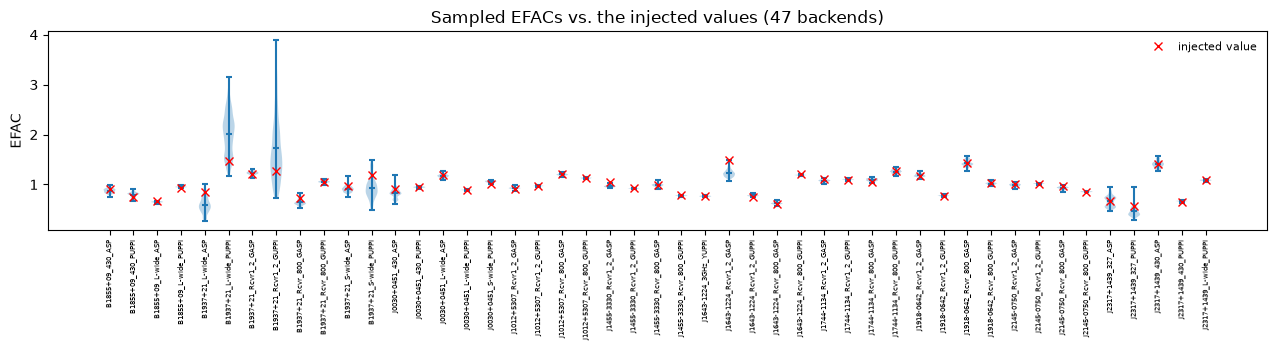

EFAC pull (mean - injected)/sd :  median -0.13, 16-84% [-1.16, +0.82]


In [30]:
# White noise: did it stay at the injected values, and with what width?
fig, ax = plt.subplots(figsize=(13, 3.6))
efac_idx = [i for i, nm in enumerate(wn_names) if nm.endswith("_efac")]
ax.violinplot([wn_chain[:, i] for i in efac_idx], showmeans=True)
ax.plot(range(1, len(efac_idx) + 1), np.asarray(wn_true)[efac_idx],
        "rx", ms=6, label="injected value")
ax.set_xticks(range(1, len(efac_idx) + 1))
ax.set_xticklabels([wn_names[i].replace("_efac", "") for i in efac_idx],
                   rotation=90, fontsize=5)
ax.set_ylabel("EFAC"); ax.legend(fontsize=8, frameon=False)
ax.set_title(f"Sampled EFACs vs. the injected values ({len(efac_idx)} backends)")
plt.tight_layout(); plt.show()

pulls = [(wn_chain[:, i].mean() - wn_true[i]) / wn_chain[:, i].std() for i in efac_idx]
print(f"EFAC pull (mean - injected)/sd :  median {np.median(pulls):+.2f}, "
      f"16-84% [{np.percentile(pulls,16):+.2f}, {np.percentile(pulls,84):+.2f}]")

This plot is the whole argument for a global fit in one picture: those EFAC posteriors
have **width**, and that width is propagating into the GWB posterior. In a staged
analysis every one of those parameters would have been frozen at a point estimate — at
the red cross if you were lucky, and at whatever a separate single-pulsar noise run
produced if you were not.

The pull statistic underneath is the quantitative version: with the chain initialised at
the truth, it says how far each posterior has wandered in units of its own width. Here the
median pull is $-0.22$ with a 16–84% range of $[-1.05, +0.81]$ — scattered around zero with
unit spread, which is what a correct sampler on correctly-modelled data gives. It also
retires the EQUAD-convention worry from §1: a mismatch there would have shown up as a
systematic offset in these pulls, and it did not.

z_a: (1000, 10, 382)


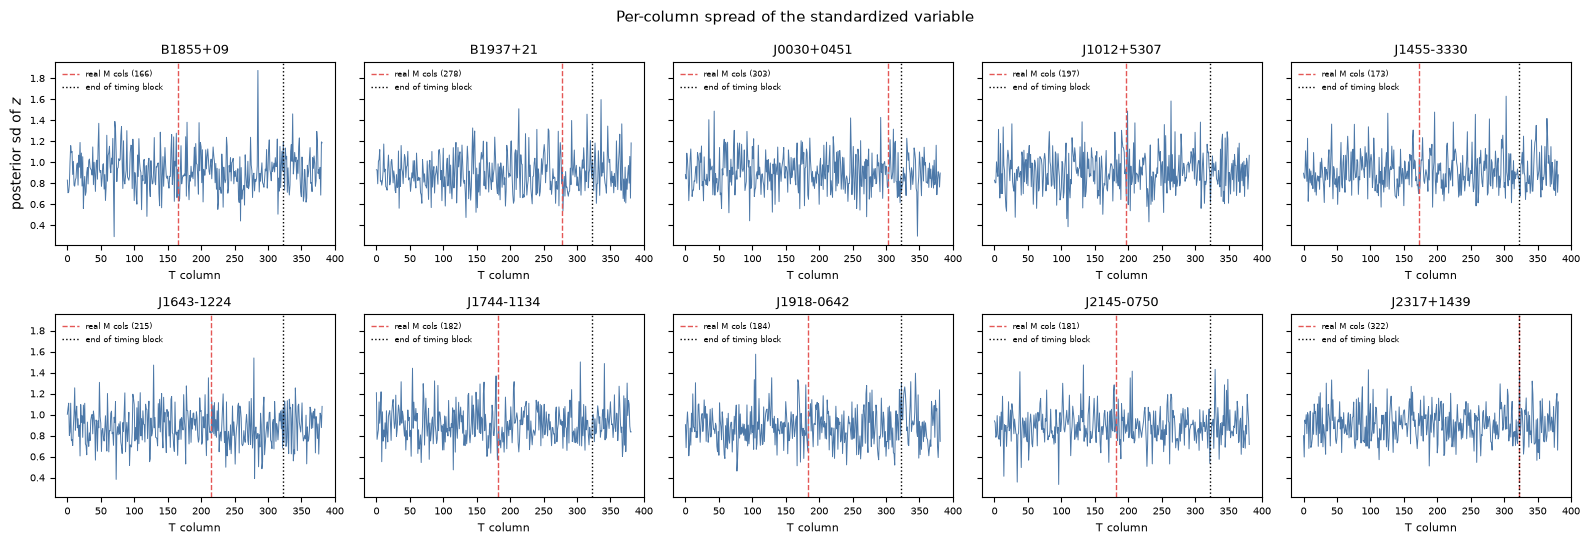

In [31]:
# The sampled linear timing-model coefficients live in z_a's timing columns.
z_chain = np.asarray(samples["z_a"])           # [nsamples, npsr, nmodes]
print("z_a:", z_chain.shape)

fig, axes = plt.subplots(2, 5, figsize=(16, 5.5), sharey=True)
for ax, (pidx, name) in zip(axes.ravel(), enumerate(data.psr_names)):
    n_real = int(data.Mmat[pidx].shape[1])
    sd = z_chain[:, pidx, :].std(axis=0)
    ax.plot(sd, lw=.7, color="#4c78a8")
    ax.axvline(n_real, color="#e45756", ls="--", lw=1, label=f"real M cols ({n_real})")
    ax.axvline(rn.linear_timing_model_size, color="k", ls=":", lw=1, label="end of timing block")
    ax.set_title(name, fontsize=9); ax.set_xlabel("T column", fontsize=8)
    ax.tick_params(labelsize=7); ax.legend(fontsize=6, frameon=False)
axes[0, 0].set_ylabel("posterior sd of $z$")
fig.suptitle("Per-column spread of the standardized variable", fontsize=11)
plt.tight_layout(); plt.show()

Between the red dashed line and the black dotted line are the **padded dummy columns**.
Their $z$ has unit spread by construction (that is the `_pad_mask` unit-variance Gaussian
doing its job) and they carry no information — a useful visual check that the padding
scheme is behaving. J2317+1439, which sets the padded width, has no gap at all; B1855+09
has the largest.

---
# 13. What to change, and what to watch out for

## Where to look, given what you want to change

| Goal | Where |
|---|---|
| New spectral shape | `psd_functions.py` — write `f(f, df, *params)`, pass as `irn_psd_function` / `gwb_psd_function` |
| New ORF | `psd_functions.py` (**not** `signals/orf_functions.py`, which is vestigial) — signature `f(angle, *params)` |
| Fix a spectral parameter | wrap in `functools.partial`, e.g. `partial(powerlaw, gamma=13/3)` |
| Change the white-noise model | `nMatrix/base.py` — `get_nvec_jvec`, `_solve_unmarg` |
| Change the likelihood/transform | `factorized/base.py:1202–1413` — and **check the matching `numpyro.factor` correction** |
| Gibbs blocking instead of one big NUTS | `canetoadracing.py` — `MultiHMCGibbs.gibbs_sites_list` |
| Label posterior samples | `rn.model.get_param_names()`, `wn.get_param_names()` |
| Make another simulated dataset | `notebooks/[KAG]Generating_P1_data.ipynb`, or `ATLAS/sim.py` for injections directly onto residuals |

## Traps in the current codebase

* **Construction order.** White noise **must** be built before red noise (§3). Unenforced.
* **Injected-parameter key names.** `injected_params.json` uses `_equad` / `_ecorr`;
  ATLAS uses `_log10_t2equad` / `_log10_ecorr` (§1). `params_dict_to_vector` fails with a
  bare `KeyError` if you skip the rename.
* **`dm` is broken.** Any model string containing `dm` raises `AttributeError`:
  `PTA_Data` stores the argument as `self.dm_bins` but `make_red_noise` reads
  `self.data.num_dm_bins`. DM noise is unreachable through the public API until that
  attribute is renamed.
* **`ltm|` is silently ignored unless the string has a shared group.** `build_basis`
  (`factorized/base.py:940-948`) only prepends the timing design matrix inside the *shared*
  block. With `"ltm|unc;cor"` — or even plain `"ltm|unc"`, the natural single-pulsar noise
  string — the prefix is parsed, `signal_comb_idxs` reserves columns
  `[0, linear_timing_model_size)` for `timing`, and **M is never concatenated**: $T$ comes
  out 88 columns wide while the bookkeeping claims 410. No error, and every downstream
  slice is wrong. Check `rn.get_Fmat_concat.shape[1] == rn.nmodes` against
  `linear_timing_model_size + 2*(nbins)` whenever you use a `;` string.
* **Partial marginalisation needs `gtm`, and needs more than that.**
  `marg_over_non_gwb=True` first raises `KeyError: 'gtm'` (`base.py:1326` indexes it
  unconditionally). Patching that is not enough: see the measurement in §11 — with `cor` in
  its own block the GWB columns duplicate the IRN columns exactly and the sampler freezes.
* **ORF bounds in the reference script are inverted.** See the warning in §4.
* **`ln_likelihood_curn` has no caller** anywhere in the repo. It is a correct reference
  implementation of the Enterprise-style marginal likelihood (coefficients integrated out,
  $\phi$ strictly diagonal, no cross-pulsar correlation) and is genuinely useful for
  validating a CURN run against a known-good result — but you have to wire it yourself.
  On *this* dataset that validation is unusually cheap to interpret, because the answer is
  in `injected_params.json`.
* **`SuperSignal.model_maker` vs `canetoadracing.model_maker`** are unrelated things with
  the same name. Grep for one and you find the other.
* **GPU memory.** Cap `XLA_PYTHON_CLIENT_MEM_FRACTION` at ~0.45 before importing JAX (§0).
  Leave it at the default and this exact notebook dies ~30 minutes into warmup with
  `CUDA_ERROR_OUT_OF_MEMORY` on a *kernel load*, not on a data allocation — a failure that
  looks like the dataset is too big when in fact the pool needs to be made smaller.

## Scaling this up

Going from 10 pulsars to 67 changes which choices are affordable:

1. **Get white noise out of the joint gradient — this is the whole ballgame.** §11 measures
   it: fixed white noise is ~20× cheaper per gradient *and* ~11× better mixing, about 220×
   more effective samples per second. Rebuilding `helpers` every leapfrog step over ~500k
   TOAs is brutal, and it is *also* what ruins the geometry. The principled version is
   `MultiHMCGibbs` in `canetoadracing.py` with `gibbs_sites_list=[['white_noise'],
   ['red_noise','z_a']]`. Note the sharp edge: blocking alone recovers the *mixing* win but
   not the *cost* win, because `model_maker` calls `get_helpers()` whenever
   `vary_white=True` — so the red block still rebuilds $T^\mathsf{T}N^{-1}T$ on every
   gradient even though white noise is frozen within that block. Capturing both needs a
   model that accepts precomputed `helpers` for the red block.
2. **Do not expect `marg_over_non_gwb=True` to save you** — see §11 and the traps above. The
   latent dimension it removes is real (3,820 → 280), but not reachable for an IRN+GWB model.
3. **Do not split the GWB spectrum from the IRN spectra into different Gibbs blocks.**
   They are severely degenerate — a common process is absorbable into $N_\mathrm{psr}$
   individual ones, and in our model string the GWB literally occupies the same columns as
   the IRN. Gibbs on strongly correlated Gaussians pays a $1/(1-\rho^2)$ mixing penalty
   with $\rho$ routinely above 0.9. The per-pulsar IRN plot in §12 is the diagnostic to
   watch.
4. **Choose the sub-array for the signal, not for the baseline.** §12 is a worked example
   of getting this wrong: ten long-baseline pulsars, six of them injected with intrinsic red
   noise at or above the GWB level, give an upper limit rather than a recovery.
5. **Validate on simulations first.** That is what this dataset is for: `sim_NG15_01` has
   the real array's cadence and design matrices, so a configuration that cannot recover
   $A = 2.4\times10^{-15}$ on a well-chosen sub-array will not be trustworthy on
   `datasets/NG15`.